In [1]:
import torch
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
root_cub = os.path.join("experiments", "scbm_residual", "CUB")

# # 50 residuals
EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_1_2026-07-30_17-04-11_72f02")

# # 20 residuals
# EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-07-31_20-15-47_174e5")

# 5 residuals
# EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-07-31_20-15-47_496cf")



## Dataset information

In [3]:
ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]

with open(os.path.join("datasets", "CUB", "CUB_200_2011", "attributes.txt"), 'r') as f:
    all_attributes_orig_idx = {}
    
    lines = f.readlines()
    for line in lines:
        idx, attr_name = line.strip().split(" ")
        #attr_group, attr_name = attr_name.split("::")  
        # 0-based indexing
        all_attributes_orig_idx[int(idx) - 1] = attr_name
  
# Map between 112 concept idx and attribute name      
sample_112_concepts_map = {new_idx: all_attributes_orig_idx[orig_idx] for new_idx, orig_idx in enumerate(ATTRIBUTES_IDX_USED)}
attr_groups__112_concepts = list(set(attr_name.split("::")[0] for attr_name in sample_112_concepts_map.values()))

print(sample_112_concepts_map)
print(attr_groups__112_concepts)
print(len(attr_groups__112_concepts))


{0: 'has_bill_shape::dagger', 1: 'has_bill_shape::hooked_seabird', 2: 'has_bill_shape::all-purpose', 3: 'has_bill_shape::cone', 4: 'has_wing_color::brown', 5: 'has_wing_color::grey', 6: 'has_wing_color::yellow', 7: 'has_wing_color::black', 8: 'has_wing_color::white', 9: 'has_wing_color::buff', 10: 'has_upperparts_color::brown', 11: 'has_upperparts_color::grey', 12: 'has_upperparts_color::yellow', 13: 'has_upperparts_color::black', 14: 'has_upperparts_color::white', 15: 'has_upperparts_color::buff', 16: 'has_underparts_color::brown', 17: 'has_underparts_color::grey', 18: 'has_underparts_color::yellow', 19: 'has_underparts_color::black', 20: 'has_underparts_color::white', 21: 'has_underparts_color::buff', 22: 'has_breast_pattern::solid', 23: 'has_breast_pattern::striped', 24: 'has_breast_pattern::multi-colored', 25: 'has_back_color::brown', 26: 'has_back_color::grey', 27: 'has_back_color::yellow', 28: 'has_back_color::black', 29: 'has_back_color::white', 30: 'has_back_color::buff', 31: '

In [4]:
# Read dataset dir from the log file in the experiment path
import ast


info_dataset_path = os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", "info.txt")


with open(info_dataset_path, 'r') as f:
    lines = f.readlines()

    for line in lines:
        if "New attribute indices mapping: " in line:
            new_attribute_mapping_string = line.split("New attribute indices mapping: ")[1].strip()
            
        if "Removed attribute groups: " in line:
            removed_attribute_groups_string = line.split("Removed attribute groups: ")[1].strip()
            

# Original has 112 attributes, but we only use a subset of them
new_attribute_mapping = ast.literal_eval(new_attribute_mapping_string)

# Removed groups list
removed_attribute_groups = ast.literal_eval(removed_attribute_groups_string)
    

        
        
concept_names_new_idx_map = {}
for orig_idx, new_idx in new_attribute_mapping.items():
    concept_names_new_idx_map[new_idx] = sample_112_concepts_map[orig_idx]


df = pd.DataFrame(list(concept_names_new_idx_map.items()), columns=['New Index', 'Concept Name'])
df.to_csv("delete_afterwards/concept_names_new_idx_map.csv", index=False)
display(df.sort_values(by='New Index').reset_index(drop=True))

# Number of attrbutes removed
print(f"Number of attributes removed: {112 - len(concept_names_new_idx_map.keys())}")





,New Index,Concept Name
0,0,has_bill_shape::dagger
1,1,has_bill_shape::hooked_seabird
2,2,has_bill_shape::all-purpose
3,3,has_bill_shape::cone
4,4,has_head_pattern::eyebrow
5,5,has_head_pattern::plain
6,6,has_breast_color::brown
7,7,has_breast_color::grey
8,8,has_breast_color::yellow
9,9,has_breast_color::black


Number of attributes removed: 90


### Check that the attribute groups in the above df is the same as the attribute groups kept for data generation

This is a security check


In [5]:
# Check if the concept name in the df matches the attribute groups that were used: attr_groups_unique
attr_groups_from_df = df["Concept Name"].apply(lambda name: name.split("::")[0])

attr_groups_from_df = list(attr_groups_from_df.unique())


kept_attr_groups_from_info = [group for group in attr_groups__112_concepts if group not in removed_attribute_groups]

# Check if the kept attribute groups from the info file match the attribute groups from the df
print(f"same attribute groups: {set(kept_attr_groups_from_info) == set(attr_groups_from_df)}")


same attribute groups: True


### Missing concepts 

In [6]:
missing_concept_names = [sample_112_concepts_map[orig_idx] for orig_idx in range(112) if orig_idx not in new_attribute_mapping.keys()]
print(missing_concept_names)

['has_wing_color::brown', 'has_wing_color::grey', 'has_wing_color::yellow', 'has_wing_color::black', 'has_wing_color::white', 'has_wing_color::buff', 'has_upperparts_color::brown', 'has_upperparts_color::grey', 'has_upperparts_color::yellow', 'has_upperparts_color::black', 'has_upperparts_color::white', 'has_upperparts_color::buff', 'has_underparts_color::brown', 'has_underparts_color::grey', 'has_underparts_color::yellow', 'has_underparts_color::black', 'has_underparts_color::white', 'has_underparts_color::buff', 'has_breast_pattern::solid', 'has_breast_pattern::striped', 'has_breast_pattern::multi-colored', 'has_back_color::brown', 'has_back_color::grey', 'has_back_color::yellow', 'has_back_color::black', 'has_back_color::white', 'has_back_color::buff', 'has_tail_shape::notched_tail', 'has_upper_tail_color::brown', 'has_upper_tail_color::grey', 'has_upper_tail_color::black', 'has_upper_tail_color::white', 'has_upper_tail_color::buff', 'has_throat_color::grey', 'has_throat_color::yell

## Most activated samples in test set for different residuals

In [7]:
scbm_res_model = torch.load(os.path.join(EXPERIMENT_PATH, "model.pth"), map_location="cpu")

# What's in there
for k, v in scbm_res_model.items():
    if k.startswith("head"):
        print(k, tuple(v.shape))

# Last linear layer of the head (head.0 for linear head, head.2 for the MLP head)
head_idx = max(int(re.match(r"head\.(\d+)\.weight", k).group(1))
               for k in scbm_res_model if re.match(r"head\.\d+\.weight", k))
W = scbm_res_model[f"head.{head_idx}.weight"]        # [pred_dim, num_concepts + num_residuals]
b = scbm_res_model[f"head.{head_idx}.bias"]          # [pred_dim]
print(f"head.{head_idx}: W {tuple(W.shape)}, b {tuple(b.shape)}")


print(W.shape)

head.0.weight (200, 72)
head.0.bias (200,)
head.0: W (200, 72), b (200,)
torch.Size([200, 72])


### Most important residuals per sample

In [8]:
import os
import re
import torch


# ============================================================
# 1. Load and verify the linear prediction head
# ============================================================

checkpoint = torch.load(
    os.path.join(EXPERIMENT_PATH, "model.pth"),
    map_location="cpu",
)

# Support checkpoints saved either directly as a state_dict
# or inside a "state_dict" entry.
if (
    isinstance(checkpoint, dict)
    and "state_dict" in checkpoint
    and isinstance(checkpoint["state_dict"], dict)
):
    scbm_res_model = checkpoint["state_dict"]
else:
    scbm_res_model = checkpoint


# Print all head parameters.
for key, value in scbm_res_model.items():
    if key.startswith("head"):
        print(key, tuple(value.shape))


# Find linear layers in the prediction head.
head_weight_keys = [
    key
    for key in scbm_res_model
    if re.fullmatch(r"head\.\d+\.weight", key)
]

if len(head_weight_keys) == 0:
    raise ValueError("No linear prediction-head weights were found.")


# This analysis assumes that the selected layer directly maps
# [concepts, residuals] to class logits.
head_idx = max(
    int(
        re.fullmatch(
            r"head\.(\d+)\.weight",
            key,
        ).group(1)
    )
    for key in head_weight_keys
)

W = scbm_res_model[
    f"head.{head_idx}.weight"
].detach().float()

b = scbm_res_model[
    f"head.{head_idx}.bias"
].detach().float()

print(
    f"head.{head_idx}: "
    f"W {tuple(W.shape)}, "
    f"b {tuple(b.shape)}"
)


# Bottleneck dimensions.
C = NUM_CONCEPTS = 22
R = NUM_RESIDUALS = W.shape[1] - C

if R <= 0:
    raise ValueError(
        f"Invalid residual dimension R={R}. "
        f"Head input dimension={W.shape[1]}, C={C}."
    )

print(f"Number of concepts: {C}")
print(f"Number of residuals: {R}")


# Split the prediction-head weights.
W_c = W[:, :C]   # [K, C]
W_r = W[:, C:]   # [K, R]

assert W_c.shape[1] == C
assert W_r.shape[1] == R
assert W.shape[1] == C + R


# ============================================================
# 2. Convert prediction logits to class probabilities
# ============================================================

y_pred_logits = torch.load(
    os.path.join(
        EXPERIMENT_PATH,
        "test",
        "y_pred.pt",
    ),
    map_location="cpu",
).float()

y_true = torch.load(
    os.path.join(
        EXPERIMENT_PATH,
        "test",
        "y_true.pt",
    ),
    map_location="cpu",
).long().view(-1)


if y_pred_logits.ndim != 2:
    raise ValueError(
        "Expected y_pred logits to have shape [N, K], "
        f"but received {tuple(y_pred_logits.shape)}."
    )

num_samples, num_classes = y_pred_logits.shape

assert W.shape[0] == num_classes, (
    f"The head has {W.shape[0]} output classes, but "
    f"y_pred has {num_classes} classes."
)

assert y_true.shape[0] == num_samples, (
    "The number of labels does not match the number "
    "of prediction samples."
)


# Convert raw class logits into probabilities.
p_bar = torch.softmax(
    y_pred_logits,
    dim=1,
)

# Aggregated predicted class.
top1_class = y_pred_logits.argmax(dim=1)

assert p_bar.shape == y_pred_logits.shape
assert torch.allclose(
    p_bar.sum(dim=1),
    torch.ones_like(p_bar.sum(dim=1)),
    atol=1e-6,
)

print(
    "y_pred_logits.shape:",
    tuple(y_pred_logits.shape),
)

print(
    "p_bar.shape:",
    tuple(p_bar.shape),
)

print(
    "top1_class.shape:",
    tuple(top1_class.shape),
)


# ============================================================
# 3. Load Rao-Blackwellized MC activation probabilities
# ============================================================

train_probs_path = os.path.join(
    EXPERIMENT_PATH,
    "train",
    "concepts_residuals_pred_probs_mean.pt",
)

test_probs_path = os.path.join(
    EXPERIMENT_PATH,
    "test",
    "concepts_residuals_pred_probs_mean.pt",
)


train_pred_probs_mean = torch.load(
    train_probs_path,
    map_location="cpu",
).float()

test_pred_probs_mean = torch.load(
    test_probs_path,
    map_location="cpu",
).float()


if train_pred_probs_mean.ndim != 2:
    raise ValueError(
        "Expected train activation probabilities to have "
        f"shape [N_train, C + R], but received "
        f"{tuple(train_pred_probs_mean.shape)}."
    )

if test_pred_probs_mean.ndim != 2:
    raise ValueError(
        "Expected test activation probabilities to have "
        f"shape [N_test, C + R], but received "
        f"{tuple(test_pred_probs_mean.shape)}."
    )

assert train_pred_probs_mean.shape[1] == C + R, (
    f"Train activation tensor has "
    f"{train_pred_probs_mean.shape[1]} dimensions, "
    f"but expected {C + R}."
)

assert test_pred_probs_mean.shape[1] == C + R, (
    f"Test activation tensor has "
    f"{test_pred_probs_mean.shape[1]} dimensions, "
    f"but expected {C + R}."
)

assert test_pred_probs_mean.shape[0] == num_samples, (
    "The number of test activation samples does not "
    "match the number of prediction samples."
)


# MC-averaged activation probabilities:
#
#   p_mean[n, j]
#       = (1/M) sum_m sigmoid(eta[n, j, m])
#
train_c_prob_mean = train_pred_probs_mean[:, :C]
train_r_prob_mean = train_pred_probs_mean[:, C:]

test_c_prob_mean = test_pred_probs_mean[:, :C]
test_r_prob_mean = test_pred_probs_mean[:, C:]


print(
    "train_c_prob_mean.shape:",
    tuple(train_c_prob_mean.shape),
)

print(
    "train_r_prob_mean.shape:",
    tuple(train_r_prob_mean.shape),
)

print(
    "test_c_prob_mean.shape:",
    tuple(test_c_prob_mean.shape),
)

print(
    "test_r_prob_mean.shape:",
    tuple(test_r_prob_mean.shape),
)


# ============================================================
# 4. Compute train-set activation baselines
# ============================================================

# Population-average activation probability for each dimension.
c_train_base_rate = train_c_prob_mean.mean(dim=0)
r_train_base_rate = train_r_prob_mean.mean(dim=0)


# Center the test activations using train-set statistics.
centered_c = (
    test_c_prob_mean
    - c_train_base_rate.unsqueeze(0)
)

centered_r = (
    test_r_prob_mean
    - r_train_base_rate.unsqueeze(0)
)


assert centered_c.shape == (num_samples, C)
assert centered_r.shape == (num_samples, R)

print(
    "centered_c.shape:",
    tuple(centered_c.shape),
)

print(
    "centered_r.shape:",
    tuple(centered_r.shape),
)


# ============================================================
# 5. Compute probability-weighted class contrasts
# ============================================================

# Weight vectors for the predicted class:
#
#   W_top1[n, :]
#       = W[k*_n, :]
#
W_c_top1 = W_c[top1_class]  # [N, C]
W_r_top1 = W_r[top1_class]  # [N, R]


# Probability-weighted average class weights:
#
#   E_p[W_c][n, i]
#       = sum_k p_bar[n, k] W_c[k, i]
#
#   E_p[W_r][n, j]
#       = sum_k p_bar[n, k] W_r[k, j]
#
expected_W_c = p_bar @ W_c  # [N, C]
expected_W_r = p_bar @ W_r  # [N, R]


# Probability-weighted class contrasts:
#
#   u_c[n, i]
#       = W_c[k*_n, i] - sum_k p[n, k] W_c[k, i]
#
#   u_r[n, j]
#       = W_r[k*_n, j] - sum_k p[n, k] W_r[k, j]
#
u_c = W_c_top1 - expected_W_c
u_r = W_r_top1 - expected_W_r


assert u_c.shape == centered_c.shape
assert u_r.shape == centered_r.shape

print(
    "u_c.shape:",
    tuple(u_c.shape),
)

print(
    "u_r.shape:",
    tuple(u_r.shape),
)


# ============================================================
# 6. Per-sample, per-dimension centered contributions
# ============================================================

# Concept contribution:
#
#   phi_c[n, i]
#       = u_c[n, i]
#         * (c_mean[n, i] - c_train_base[i])
#
phi_c = u_c * centered_c


# Residual contribution:
#
#   phi_r[n, j]
#       = u_r[n, j]
#         * (r_mean[n, j] - r_train_base[j])
#
phi_r = u_r * centered_r

abs_phi_r = phi_r.abs()

# ============================================================
# Per-sample residual contribution shares
# ============================================================

# For each sample, normalize residual contributions so that
# they sum to 1 across residual dimensions.
residual_contribution_share = (
    abs_phi_r
    / abs_phi_r.sum(dim=1, keepdim=True).clamp_min(1e-12)
)

assert residual_contribution_share.shape == (num_samples, R)

print(
    "residual_contribution_share.shape:",
    tuple(residual_contribution_share.shape),
)

print(
    "Mean row sum:",
    residual_contribution_share.sum(dim=1).mean().item(),
)









assert phi_c.shape == (num_samples, C)
assert phi_r.shape == (num_samples, R)

print(
    "phi_c.shape:",
    tuple(phi_c.shape),
)

print(
    "phi_r.shape:",
    tuple(phi_r.shape),
)


# ============================================================
# 7. Most important residuals for each sample
# ============================================================

num_top_residuals = min(5, R)

top_residuals = torch.topk(
    abs_phi_r,
    k=num_top_residuals,
    dim=1,
)

top_residual_indices = top_residuals.indices
top_residual_abs_contributions = top_residuals.values


# Signed contribution for each selected residual.
top_residual_signed_contributions = torch.gather(
    phi_r,
    dim=1,
    index=top_residual_indices,
)


# Activation deviation for each selected residual.
top_residual_activation_deviations = torch.gather(
    centered_r,
    dim=1,
    index=top_residual_indices,
)


# Probability-weighted class contrast for each selected residual.
top_residual_weighted_contrasts = torch.gather(
    u_r,
    dim=1,
    index=top_residual_indices,
)


sample_idx = 1

print(f"\nExample: test sample {sample_idx}")
print(
    "True class:",
    y_true[sample_idx].item(),
)
print(
    "Predicted class:",
    top1_class[sample_idx].item(),
)
print(
    "Predicted probability:",
    p_bar[
        sample_idx,
        top1_class[sample_idx],
    ].item(),
)


for rank in range(num_top_residuals):
    residual_idx = top_residual_indices[
        sample_idx,
        rank,
    ].item()

    contribution = top_residual_signed_contributions[
        sample_idx,
        rank,
    ].item()

    absolute_contribution = top_residual_abs_contributions[
        sample_idx,
        rank,
    ].item()

    weighted_contrast = top_residual_weighted_contrasts[
        sample_idx,
        rank,
    ].item()

    activation_deviation = top_residual_activation_deviations[
        sample_idx,
        rank,
    ].item()

    print(
        f"Rank {rank + 1}: "
        f"residual {residual_idx} | "
        f"contribution={contribution:.6f} | "
        f"|contribution|={absolute_contribution:.6f} | "
        f"weighted contrast={weighted_contrast:.6f} | "
        f"activation deviation={activation_deviation:.6f}"
    )

head.0.weight (200, 72)
head.0.bias (200,)
head.0: W (200, 72), b (200,)
Number of concepts: 22
Number of residuals: 50
y_pred_logits.shape: (5794, 200)
p_bar.shape: (5794, 200)
top1_class.shape: (5794,)
train_c_prob_mean.shape: (4796, 22)
train_r_prob_mean.shape: (4796, 50)
test_c_prob_mean.shape: (5794, 22)
test_r_prob_mean.shape: (5794, 50)
centered_c.shape: (5794, 22)
centered_r.shape: (5794, 50)
u_c.shape: (5794, 22)
u_r.shape: (5794, 50)
residual_contribution_share.shape: (5794, 50)
Mean row sum: 1.0
phi_c.shape: (5794, 22)
phi_r.shape: (5794, 50)

Example: test sample 1
True class: 0
Predicted class: 0
Predicted probability: 0.6669815182685852
Rank 1: residual 32 | contribution=0.072763 | |contribution|=0.072763 | weighted contrast=-0.132059 | activation deviation=-0.550991
Rank 2: residual 25 | contribution=0.067880 | |contribution|=0.067880 | weighted contrast=-0.118897 | activation deviation=-0.570916
Rank 3: residual 7 | contribution=0.060440 | |contribution|=0.060440 | weig

### Per class contribution (non-normalized within class)

per_class_mean_abs_contribution.shape: (200, 50)
per_class_mean_contribution_share.shape: (200, 50)
per_class_std_contribution_share.shape: (200, 50)
Number of samples per class: [30, 30, 28, 30, 14, 11, 23, 18, 29, 30, 30, 26, 30, 30, 28, 28, 27, 15, 29, 29, 30, 26, 29, 22, 30, 30, 30, 29, 30, 30, 30, 23, 29, 29, 30, 30, 29, 30, 29, 30, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 28, 30, 29, 30, 30, 30, 30, 20, 30, 30, 30, 30, 30, 30, 30, 30, 30, 27, 30, 30, 29, 30, 30, 30, 30, 30, 23, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 30, 30, 30, 20, 30, 30, 30, 19, 30, 30, 30, 30, 30, 30, 30, 20, 30, 29, 30, 29, 30, 29, 30, 30, 30, 30, 29, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 29, 30, 21, 30, 29, 30, 30, 30, 29, 30, 30, 29, 30, 30, 30, 30, 30, 29, 30, 29, 29, 30, 30, 30, 30, 30, 30, 30, 30, 26, 29, 30, 29, 30, 30, 30, 30, 30, 20, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30]


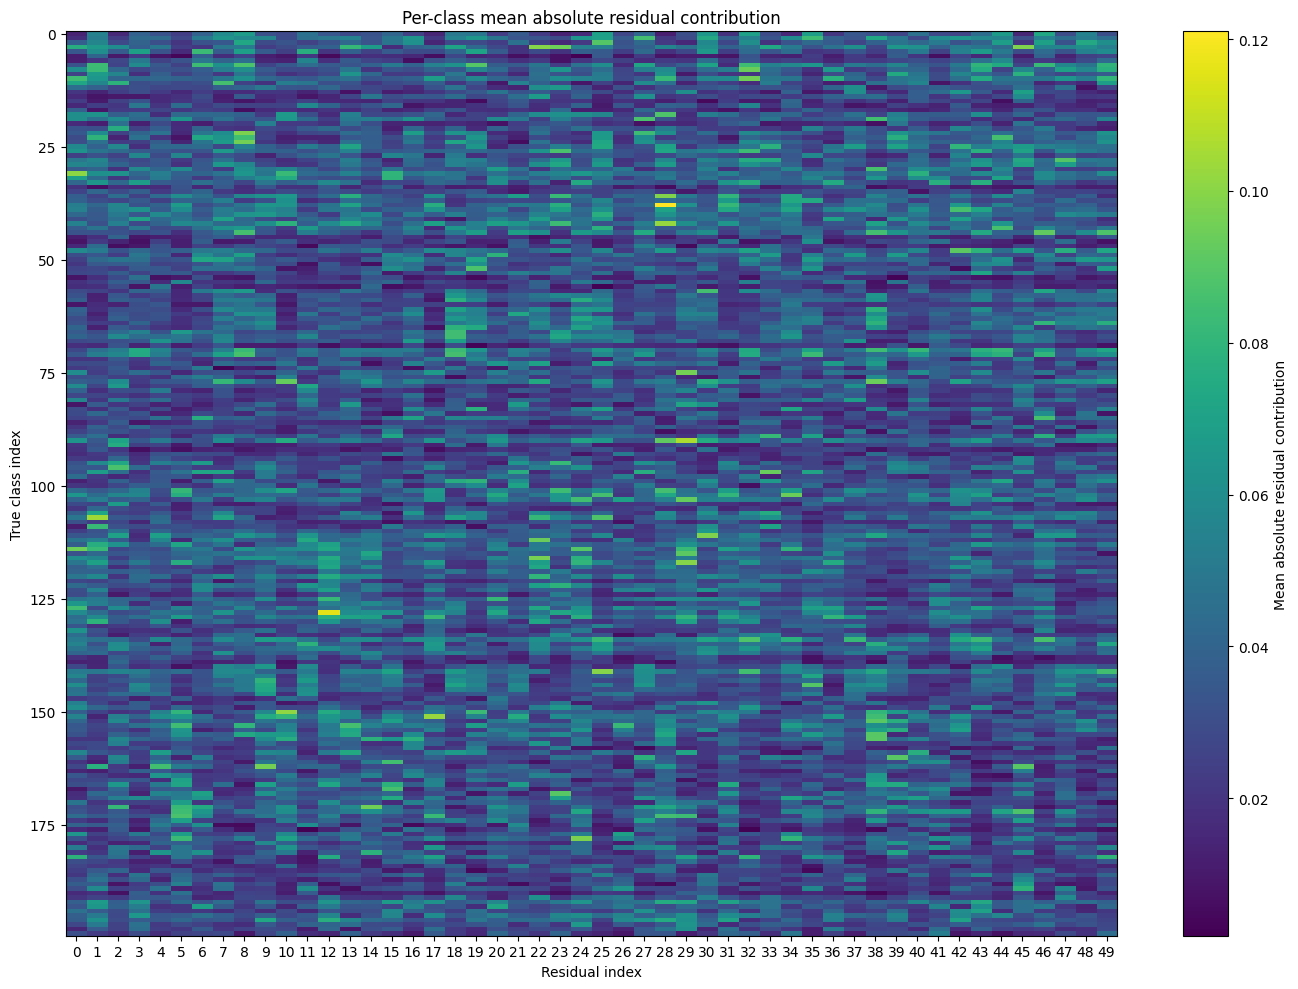

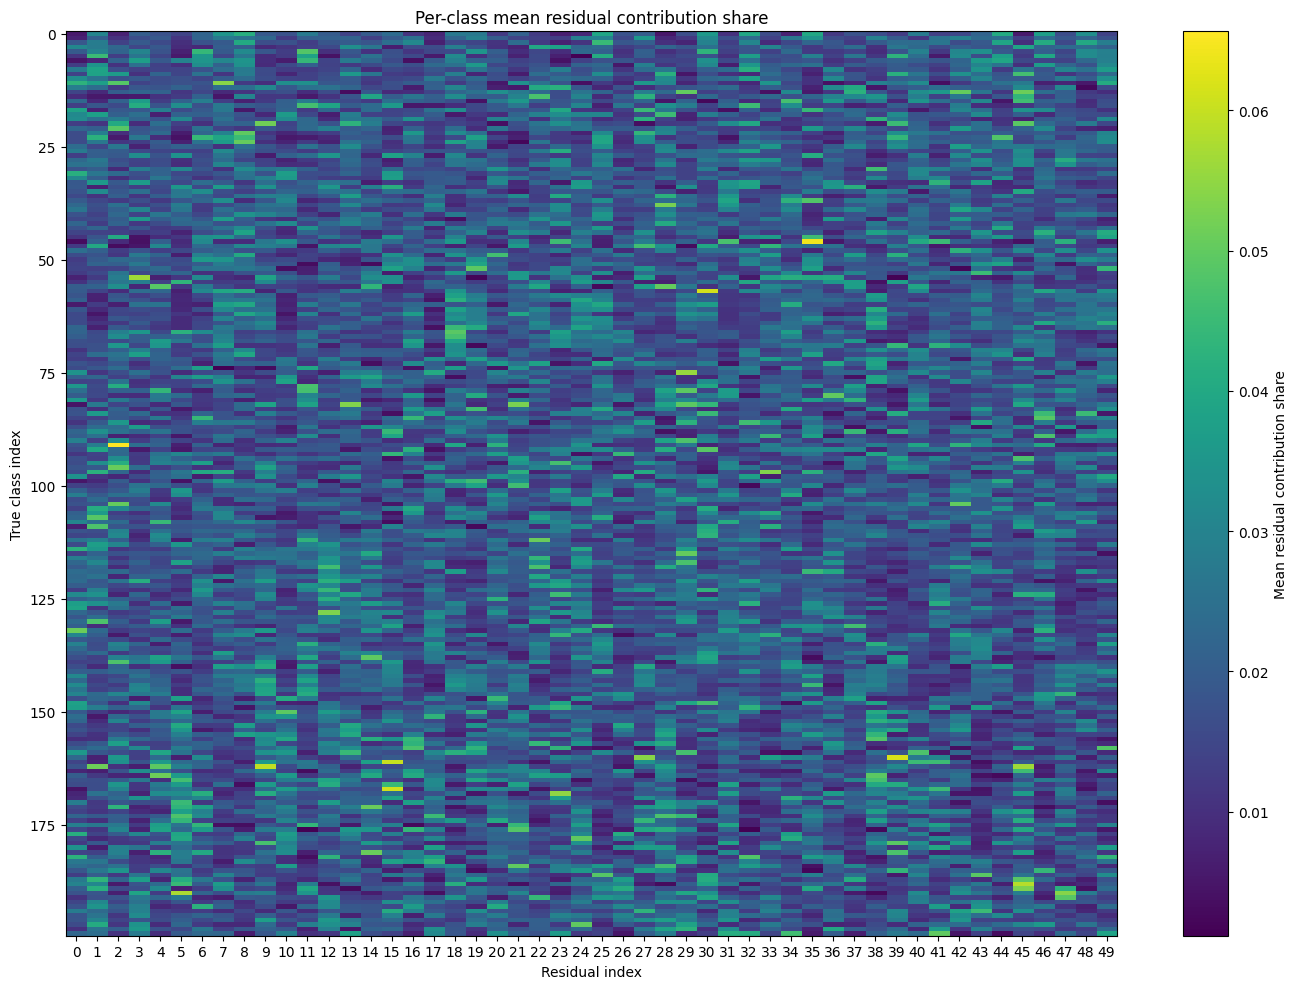

In [9]:
# ============================================================
# 8. Per-class residual contribution
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch


# Ensure labels have shape [N] and are on the same device as phi_r.
y_true = y_true.to(phi_r.device).long().view(-1)

num_samples = phi_r.shape[0]
num_classes = W.shape[0]

assert y_true.shape[0] == num_samples, (
    f"y_true contains {y_true.shape[0]} samples, "
    f"but phi_r contains {num_samples}."
)

assert top1_class.shape[0] == num_samples

assert phi_r.shape == (num_samples, R), (
    f"Expected phi_r shape {(num_samples, R)}, "
    f"but received {tuple(phi_r.shape)}."
)

assert centered_r.shape == (num_samples, R)
assert residual_contribution_share.shape == (num_samples, R)

assert y_true.min() >= 0
assert y_true.max() < num_classes


# ------------------------------------------------------------
# A. Per-class statistics using true-class membership
# ------------------------------------------------------------

# Main importance measure:
#
# I[c, j] = mean_{n: y_n = c} |phi_r[n, j]|
per_class_mean_abs_contribution = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

# Scale-free companion to the measure above:
#
# S[c, j] = mean_{n: y_n = c} residual_contribution_share[n, j]
#         = mean_{n: y_n = c} |phi_r[n, j]| / sum_j' |phi_r[n, j']|
#
# Each sample contributes equally regardless of how large its
# total residual contribution is, so this reports how the
# residual channel is *allocated* within the class rather than
# how much residual signal the class carries in absolute terms.
per_class_mean_contribution_share = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=residual_contribution_share.dtype,
    device=residual_contribution_share.device,
)

# Spread of that share across the samples of the class:
#
# std_{n: y_n = c} residual_contribution_share[n, j]
#
# A small std means the class allocates its residual channel the
# same way for every member; a large std means the mean share is
# an average over samples that disagree.
per_class_std_contribution_share = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=residual_contribution_share.dtype,
    device=residual_contribution_share.device,
)

# Mean signed contribution:
#
# mean_{n: y_n = c} phi_r[n, j]
per_class_mean_signed_contribution = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

# Mean magnitude of the centered activation:
#
# mean_{n: y_n = c} |r_bar[n, j] - r_train_base[j]|
per_class_mean_abs_activation_deviation = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=centered_r.dtype,
    device=centered_r.device,
)

# Mean signed centered activation:
#
# mean_{n: y_n = c} (r_bar[n, j] - r_train_base[j])
per_class_mean_activation_deviation = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=centered_r.dtype,
    device=centered_r.device,
)

num_samples_per_class = torch.zeros(
    num_classes,
    dtype=torch.long,
    device=phi_r.device,
)


for class_idx in range(num_classes):
    class_mask = y_true == class_idx
    class_count = int(class_mask.sum().item())

    num_samples_per_class[class_idx] = class_count

    if class_count == 0:
        continue

    class_phi_r = phi_r[class_mask]          # [N_c, R]
    class_share = residual_contribution_share[class_mask]  # [N_c, R]
    # centered_r = r_bar - r_train_base = r_bar - mean(r_bar) for train set where r_bar = r_pred_probs_mean
    class_centered_r = centered_r[class_mask]  # [N_c, R]

    per_class_mean_abs_contribution[class_idx] = (
        class_phi_r.abs().mean(dim=0)
    )

    per_class_mean_contribution_share[class_idx] = (
        class_share.mean(dim=0)
    )

    # Population standard deviation across the samples of the
    # class. correction=0 also works when the class has one
    # sample, matching the convention used for the rank spreads.
    per_class_std_contribution_share[class_idx] = (
        class_share.std(
            dim=0,
            correction=0,
        )
    )

    per_class_mean_signed_contribution[class_idx] = (
        class_phi_r.mean(dim=0)
    )

    per_class_mean_abs_activation_deviation[class_idx] = (
        class_centered_r.abs().mean(dim=0)
    )

    per_class_mean_activation_deviation[class_idx] = (
        class_centered_r.mean(dim=0)
    )


print(
    "per_class_mean_abs_contribution.shape:",
    tuple(per_class_mean_abs_contribution.shape),
)

print(
    "per_class_mean_contribution_share.shape:",
    tuple(per_class_mean_contribution_share.shape),
)

print(
    "per_class_std_contribution_share.shape:",
    tuple(per_class_std_contribution_share.shape),
)

print(
    "Number of samples per class:",
    num_samples_per_class.detach().cpu().tolist(),
)


# ============================================================
# 9. Heatmap of per-class mean absolute contribution
# ============================================================

heatmap_data = (
    per_class_mean_abs_contribution
    .detach()
    .cpu()
    .numpy()
)

# Mask classes with no samples rather than displaying NaNs as values.
heatmap_data = np.ma.masked_invalid(heatmap_data)

plt.figure(figsize=(14, 10))

image = plt.imshow(
    heatmap_data,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
)

plt.colorbar(
    image,
    label="Mean absolute residual contribution",
)

plt.xlabel("Residual index")
plt.ylabel("True class index")
plt.title("Per-class mean absolute residual contribution")

plt.xticks(
    ticks=np.arange(R),
    labels=np.arange(R),
)

plt.tight_layout()
plt.show()


# ============================================================
# 9b. Heatmap of per-class mean residual contribution share
# ============================================================

share_heatmap_data = (
    per_class_mean_contribution_share
    .detach()
    .cpu()
    .numpy()
)

share_heatmap_data = np.ma.masked_invalid(share_heatmap_data)

plt.figure(figsize=(14, 10))

share_image = plt.imshow(
    share_heatmap_data,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
)

plt.colorbar(
    share_image,
    label="Mean residual contribution share",
)

plt.xlabel("Residual index")
plt.ylabel("True class index")
plt.title("Per-class mean residual contribution share")

plt.xticks(
    ticks=np.arange(R),
    labels=np.arange(R),
)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Get mean and std rank of residual importance per class
# ============================================================

import numpy as np
import torch
from scipy.stats import rankdata


# Ensure labels are one-dimensional and on the same device.
y_true = y_true.to(phi_r.device).long().view(-1)

num_samples, num_residuals = phi_r.shape
num_classes = W.shape[0]

assert num_residuals == R, (
    f"phi_r has {num_residuals} residual dimensions, "
    f"but R={R}."
)

assert y_true.shape[0] == num_samples, (
    f"y_true has {y_true.shape[0]} samples, "
    f"but phi_r has {num_samples}."
)

assert top1_class.shape[0] == num_samples

assert y_true.min().item() >= 0
assert y_true.max().item() < num_classes


# ------------------------------------------------------------
# 1. Rank residuals for every sample
# ------------------------------------------------------------

# Rank according to absolute contribution:
#
# rank 1 = largest absolute contribution
# rank R = smallest absolute contribution
abs_phi_r = phi_r.abs()  # [N, R]


# Use average ranks for ties.
#
# Example:
# contributions = [0.8, 0.4, 0.4, 0.1]
# ranks         = [1.0, 2.5, 2.5, 4.0]
#
# The negative sign is used because scipy.rankdata assigns
# rank 1 to the smallest value by default.
abs_phi_r_np = abs_phi_r.detach().cpu().numpy()

per_sample_residual_ranks_np = np.apply_along_axis(
    lambda row: rankdata(
        -row,
        method="average",
    ),
    axis=1,
    arr=abs_phi_r_np,
)

per_sample_residual_ranks = torch.from_numpy(
    per_sample_residual_ranks_np
).to(
    device=phi_r.device,
    dtype=phi_r.dtype,
)


assert per_sample_residual_ranks.shape == (num_samples, R)

print(
    "per_sample_residual_ranks.shape:",
    tuple(per_sample_residual_ranks.shape),
)


# ============================================================
# 2. Aggregate ranks within each true class
# ============================================================

per_class_mean_rank = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_class_std_rank = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_class_median_rank = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

num_samples_per_class = torch.zeros(
    num_classes,
    dtype=torch.long,
    device=phi_r.device,
)


for class_idx in range(num_classes):
    class_mask = y_true == class_idx
    class_count = int(class_mask.sum().item())

    num_samples_per_class[class_idx] = class_count

    if class_count == 0:
        continue

    # Shape: [number of class samples, R]
    class_ranks = per_sample_residual_ranks[class_mask]

    per_class_mean_rank[class_idx] = (
        class_ranks.mean(dim=0)
    )

    # Population standard deviation across samples in the class.
    # correction=0 also works when the class has one sample.
    per_class_std_rank[class_idx] = (
        class_ranks.std(
            dim=0,
            correction=0,
        )
    )

    per_class_median_rank[class_idx] = (
        class_ranks.median(dim=0).values
    )


print(
    "per_class_mean_rank.shape:",
    tuple(per_class_mean_rank.shape),
)

print(
    "per_class_std_rank.shape:",
    tuple(per_class_std_rank.shape),
)

print(
    "per_class_median_rank.shape:",
    tuple(per_class_median_rank.shape),
)


# ============================================================
# 3. Inspect one class
# ============================================================

class_to_inspect = 1
num_to_show = min(10, R)

if not 0 <= class_to_inspect < num_classes:
    raise ValueError(
        f"class_to_inspect must be between 0 and "
        f"{num_classes - 1}, but received {class_to_inspect}."
    )

class_count = int(
    num_samples_per_class[class_to_inspect].item()
)

if class_count == 0:
    raise ValueError(
        f"Class {class_to_inspect} has no samples."
    )


# Lower mean rank means more consistently important.
residual_order = torch.argsort(
    per_class_mean_rank[class_to_inspect],
    descending=False,
)


print(
    f"\nResidual importance ranks for class "
    f"{class_to_inspect} "
    f"(n={class_count}):"
)


for position, residual_idx in enumerate(
    residual_order[:num_to_show],
    start=1,
):
    j = int(residual_idx.item())

    mean_rank = per_class_mean_rank[
        class_to_inspect,
        j,
    ].item()

    std_rank = per_class_std_rank[
        class_to_inspect,
        j,
    ].item()

    median_rank = per_class_median_rank[
        class_to_inspect,
        j,
    ].item()

    mean_abs_contribution = (
        per_class_mean_abs_contribution[
            class_to_inspect,
            j,
        ].item()
    )

    mean_contribution_share = (
        per_class_mean_contribution_share[
            class_to_inspect,
            j,
        ].item()
    )

    std_contribution_share = (
        per_class_std_contribution_share[
            class_to_inspect,
            j,
        ].item()
    )

    print(
        f"{position:2d}. residual {j:2d} | "
        f"mean rank = {mean_rank:.2f} | "
        f"std rank = {std_rank:.2f} | "
        f"median rank = {median_rank:.2f} | "
        f"mean |contribution| = "
        f"{mean_abs_contribution:.6f} | "
        f"mean share = "
        f"{mean_contribution_share:.4f} | "
        f"std share = "
        f"{std_contribution_share:.4f}"
    )

per_sample_residual_ranks.shape: (5794, 50)
per_class_mean_rank.shape: (200, 50)
per_class_std_rank.shape: (200, 50)
per_class_median_rank.shape: (200, 50)

Residual importance ranks for class 1 (n=30):
 1. residual 27 | mean rank = 10.70 | std rank = 12.43 | median rank = 6.00 | mean |contribution| = 0.085563 | mean share = 0.0353 | std share = 0.0142
 2. residual 35 | mean rank = 11.43 | std rank = 9.44 | median rank = 9.00 | mean |contribution| = 0.083401 | mean share = 0.0348 | std share = 0.0142
 3. residual 30 | mean rank = 13.63 | std rank = 10.62 | median rank = 9.00 | mean |contribution| = 0.073804 | mean share = 0.0315 | std share = 0.0114
 4. residual 19 | mean rank = 13.90 | std rank = 11.71 | median rank = 11.00 | mean |contribution| = 0.064824 | mean share = 0.0289 | std share = 0.0111
 5. residual 24 | mean rank = 15.80 | std rank = 14.46 | median rank = 10.00 | mean |contribution| = 0.064612 | mean share = 0.0291 | std share = 0.0157
 6. residual  7 | mean rank = 17.37 

### Dataframe with top 10 ranked residuals for every class

In [11]:
# ============================================================
# DataFrame with top 10 ranked residuals for every class
# ============================================================

import os
import pandas as pd
import torch


num_to_show = min(10, R)
rows = []

for class_idx in range(num_classes):
    class_count = int(
        num_samples_per_class[class_idx].item()
    )

    # Keep the class in the output even if it has no samples.
    if class_count == 0:
        for position in range(1, num_to_show + 1):
            rows.append(
                {
                    "class_idx": class_idx,
                    "num_samples": 0,
                    "residual_position": position,
                    "residual_idx": pd.NA,
                    "mean_rank": float("nan"),
                    "std_rank": float("nan"),
                    "median_rank": float("nan"),
                    "mean_abs_contribution": float("nan"),
                    "mean_per_sample_share": float("nan"),
                    "std_per_sample_share": float("nan"),
                }
            )
        continue

    # Lower mean rank means more consistently important.
    residual_order = torch.argsort(
        per_class_mean_rank[class_idx],
        descending=False,
    )

    top_residual_indices = residual_order[:num_to_show]

    for position, residual_idx in enumerate(
        top_residual_indices,
        start=1,
    ):
        j = int(residual_idx.item())

        rows.append(
            {
                "class_idx": class_idx,
                "num_samples": class_count,
                "residual_position": position,
                "residual_idx": j,
                "mean_rank": per_class_mean_rank[
                    class_idx, j
                ].item(),
                "std_rank": per_class_std_rank[
                    class_idx, j
                ].item(),
                "median_rank": per_class_median_rank[
                    class_idx, j
                ].item(),
                "mean_abs_contribution": (
                    per_class_mean_abs_contribution[
                        class_idx, j
                    ].item()
                ),
                "mean_per_sample_share": (
                    per_class_mean_contribution_share[
                        class_idx, j
                    ].item()
                ),
                "std_per_sample_share": (
                    per_class_std_contribution_share[
                        class_idx, j
                    ].item()
                ),
            }
        )


top10_residuals_per_class_df = pd.DataFrame(rows)

# Make nullable integer columns.
top10_residuals_per_class_df["class_idx"] = (
    top10_residuals_per_class_df["class_idx"]
    .astype("Int64")
)

top10_residuals_per_class_df["residual_position"] = (
    top10_residuals_per_class_df["residual_position"]
    .astype("Int64")
)

top10_residuals_per_class_df["residual_idx"] = (
    top10_residuals_per_class_df["residual_idx"]
    .astype("Int64")
)

print(
    "DataFrame shape:",
    top10_residuals_per_class_df.shape,
)


top10_residuals_per_class_df.to_csv("delete_afterwards/top10_residuals_per_class.csv", index=False)


display(top10_residuals_per_class_df.head(20))




DataFrame shape: (2000, 10)


,class_idx,num_samples,residual_position,residual_idx,mean_rank,std_rank,median_rank,mean_abs_contribution,mean_per_sample_share,std_per_sample_share
0,0,30,1,8,9.333333,10.621780,5.0,0.067850,0.041466,0.016314
1,0,30,2,30,9.833333,5.983774,8.0,0.065013,0.036132,0.012695
2,0,30,3,25,9.866667,10.062251,6.0,0.069135,0.038975,0.014720
3,0,30,4,32,10.633333,12.856861,5.0,0.068982,0.039416,0.016958
4,0,30,5,35,11.533334,14.741627,4.0,0.068229,0.039730,0.017766
5,0,30,6,46,12.200000,12.207648,8.0,0.073202,0.037342,0.019207
6,0,30,7,48,12.833333,10.292662,9.0,0.054078,0.033041,0.014011
7,0,30,8,44,13.100000,15.501290,4.0,0.066602,0.040635,0.024133
8,0,30,9,7,13.566667,14.739252,7.0,0.058327,0.034759,0.017202
9,0,30,10,1,13.700000,9.822253,9.0,0.054085,0.030553,0.011081


In [12]:
### Get class_names ###
with open(os.path.join("datasets", "CUB", "CUB_200_2011", "CUB_200_2011", "classes.txt"), "r") as f:
    class_names_names = [line.strip().split(" ")[1] for line in f.readlines()]




# ============================================================
# DataFrame with all ranked residuals for every class
# ============================================================

import os
import pandas as pd
import torch


num_to_show = NUM_RESIDUALS

rows = []

for class_idx in range(num_classes):
    class_count = int(
        num_samples_per_class[class_idx].item()
    )

    # Keep the class in the output even if it has no samples.
    if class_count == 0:
        for position in range(1, num_to_show + 1):
            rows.append(
                {
                    "class_idx": class_idx,
                    "class_name": class_names_names[class_idx],
                    "num_samples": 0,
                    "residual_position": position,
                    "residual_idx": pd.NA,
                    "mean_rank": float("nan"),
                    "std_rank": float("nan"),
                    "median_rank": float("nan"),
                    "mean_abs_contribution": float("nan"),
                    "mean_per_sample_share": float("nan"),
                    "std_per_sample_share": float("nan"),
                }
            )
        continue

    # Lower mean rank means more consistently important.
    residual_order = torch.argsort(
        per_class_mean_rank[class_idx],
        descending=False,
    )

    top_residual_indices = residual_order[:num_to_show]

    for position, residual_idx in enumerate(
        top_residual_indices,
        start=1,
    ):
        j = int(residual_idx.item())

        rows.append(
            {
                "class_idx": class_idx,
                "class_name": class_names_names[class_idx],
                "num_samples": class_count,
                "residual_position": position,
                "residual_idx": j,
                "mean_rank": per_class_mean_rank[
                    class_idx, j
                ].item(),
                "std_rank": per_class_std_rank[
                    class_idx, j
                ].item(),
                "median_rank": per_class_median_rank[
                    class_idx, j
                ].item(),
                "mean_abs_contribution": (
                    per_class_mean_abs_contribution[
                        class_idx, j
                    ].item()
                ),
                "mean_per_sample_share": (
                    per_class_mean_contribution_share[
                        class_idx, j
                    ].item()
                ),
                "std_per_sample_share": (
                    per_class_std_contribution_share[
                        class_idx, j
                    ].item()
                ),
            }
        )


all_residuals_per_class_df = pd.DataFrame(rows)

# Make nullable integer columns.
all_residuals_per_class_df["class_idx"] = (
    all_residuals_per_class_df["class_idx"]
    .astype("Int64")
)

all_residuals_per_class_df["residual_position"] = (
    all_residuals_per_class_df["residual_position"]
    .astype("Int64")
)

all_residuals_per_class_df["residual_idx"] = (
    all_residuals_per_class_df["residual_idx"]
    .astype("Int64")
)

print(
    "DataFrame shape:",
    all_residuals_per_class_df.shape,
)


all_residuals_per_class_df.to_csv("delete_afterwards/all_residuals_per_class.csv", index=False)


display(all_residuals_per_class_df.head(70))




DataFrame shape: (10000, 11)


,class_idx,class_name,num_samples,residual_position,residual_idx,mean_rank,std_rank,median_rank,mean_abs_contribution,mean_per_sample_share,std_per_sample_share
0,0,001.Black_footed_Albatross,30,1,8,9.333333,10.621780,5.0,0.067850,0.041466,0.016314
1,0,001.Black_footed_Albatross,30,2,30,9.833333,5.983774,8.0,0.065013,0.036132,0.012695
2,0,001.Black_footed_Albatross,30,3,25,9.866667,10.062251,6.0,0.069135,0.038975,0.014720
3,0,001.Black_footed_Albatross,30,4,32,10.633333,12.856861,5.0,0.068982,0.039416,0.016958
4,0,001.Black_footed_Albatross,30,5,35,11.533334,14.741627,4.0,0.068229,0.039730,0.017766
...,...,...,...,...,...,...,...,...,...,...,...
65,1,002.Laysan_Albatross,30,16,12,21.966667,8.573150,20.0,0.049144,0.021196,0.007338
66,1,002.Laysan_Albatross,30,17,6,22.366667,14.079496,17.0,0.051518,0.021935,0.011677
67,1,002.Laysan_Albatross,30,18,9,22.466667,14.945977,18.0,0.056051,0.022769,0.015467
68,1,002.Laysan_Albatross,30,19,18,22.666666,14.974051,20.0,0.054477,0.022133,0.014085


In [13]:
all_residuals_per_class_df["mean_abs_contribution_rank"] = (
    all_residuals_per_class_df
    .groupby("class_idx")["mean_abs_contribution"]
    .rank(
        method="first",
        ascending=False
    )
)

all_residuals_per_class_df["mean_per_sample_share_rank"] = (
    all_residuals_per_class_df
    .groupby("class_idx")["mean_per_sample_share"]
    .rank(
        method="first",
        ascending=False
    )
)

residual_summary = (
    all_residuals_per_class_df
    .dropna(subset=["residual_idx"])
    .groupby("residual_idx")
    .agg(
        num_classes_top10_by_mean_rank=(
            "residual_position",
            lambda x: (x <= 10).sum()
        ),

        num_classes_top10_by_mean_abs_contribution=(
            "mean_abs_contribution_rank",
            lambda x: (x <= 10).sum()
        ),

        num_classes_top10_by_mean_per_sample_share=(
            "mean_per_sample_share_rank",
            lambda x: (x <= 10).sum()
        ),

        num_classes_median_rank_leq_10=(
            "median_rank",
            lambda x: (x <= 10).sum()
        ),

        num_classes_median_rank_leq_5=(
            "median_rank",
            lambda x: (x <= 5).sum()
        ),

        avg_mean_rank_position=(
            "residual_position",
            "mean"
        ),

        avg_median_rank=(
            "median_rank",
            "mean"
        ),

        avg_rank_std=(
            "std_rank",
            "mean"
        ),

        avg_mean_abs_contribution=(
            "mean_abs_contribution",
            "mean"
        ),

        avg_mean_per_sample_share=(
            "mean_per_sample_share",
            "mean"
        ),

        avg_within_class_std_share=(
            "std_per_sample_share",
            "mean"
        ),
    )
    .reset_index()
    .sort_values(
        "num_classes_median_rank_leq_10",
        ascending=False
    )
)

display(residual_summary.head(50))

residual_summary.to_csv("delete_afterwards/residual_summary.csv", index=False)

,residual_idx,num_classes_top10_by_mean_rank,num_classes_top10_by_mean_abs_contribution,num_classes_top10_by_mean_per_sample_share,num_classes_median_rank_leq_10,num_classes_median_rank_leq_5,avg_mean_rank_position,avg_median_rank,avg_rank_std,avg_mean_abs_contribution,avg_mean_per_sample_share,avg_within_class_std_share
18,18,52,53,53,44,12,24.43,23.685,10.599262,0.035921,0.020774,0.010028
25,25,51,51,53,43,17,24.615,23.810,10.563437,0.036631,0.020560,0.009996
28,28,56,57,53,43,19,22.345,22.195,10.606370,0.039284,0.022349,0.010545
23,23,43,49,51,43,16,25.34,24.185,10.557733,0.036033,0.020709,0.010180
38,38,50,54,54,40,19,26.13,25.265,9.823250,0.036606,0.020225,0.009702
9,9,57,48,51,40,11,22.795,22.710,10.437050,0.037490,0.021457,0.009665
40,40,40,35,36,39,6,23.895,23.220,10.279005,0.035209,0.020594,0.009248
35,35,42,43,44,39,23,26.18,24.725,10.282036,0.034807,0.020399,0.009920
30,30,49,43,47,38,21,25.025,24.090,9.985343,0.035952,0.020742,0.009490
45,45,46,50,45,37,23,25.39,24.030,10.186392,0.036006,0.021141,0.009741


### Get importance of residual for genus level

In [14]:

import pandas as pd

CLASSES_PATH = os.path.join("datasets", "CUB", "CUB_hierarchy", "classes_wikispecies.txt")
HIERARCHY_PATH = os.path.join("datasets", "CUB", "CUB_hierarchy", "hierarchy_flat.txt")
with open(os.path.join("datasets", "CUB", "CUB_200_2011", "CUB_200_2011", "classes.txt"), "r") as f:
    class_names_names = [line.strip().split(" ")[1] for line in f.readlines()]


# ============================================================
# 1. Read the 200 CUB classes
# ============================================================

records = []

with open(CLASSES_PATH, "r") as f:
    for line in f:
        parts = line.strip().split(maxsplit=1)

        cub_class_id = int(parts[0])
        scientific_name = parts[1]

        records.append({
            "cub_class_id": cub_class_id,
            "scientific_name": scientific_name,
            "class_name": class_names_names[cub_class_id - 1],
        })

classes_df = pd.DataFrame(records)

# Your model uses 0,...,199
classes_df["class_idx"] = classes_df["cub_class_id"] - 1

print(classes_df.shape)
print(classes_df.head())


# ============================================================
# 2. Parse hierarchy_flat.txt
# ============================================================

# The 200 actual CUB classes
cub_class_names = set(classes_df["scientific_name"])

records = []

current_order = None
current_family = None
current_genus = None

with open(HIERARCHY_PATH, "r") as f:
    for raw_line in f:

        line = raw_line.rstrip()

        if not line.strip():
            continue

        stripped = line.lstrip("-")
        num_dashes = len(line) - len(stripped)

        name = stripped.strip()

        # Root
        if num_dashes == 0:
            continue

        # Order
        elif num_dashes == 2:
            current_order = name
            current_family = None
            current_genus = None

        # Family
        elif num_dashes == 4:
            current_family = name
            current_genus = None

        # Genus
        elif num_dashes == 6:
            current_genus = name

            # Some CUB classes are only resolved to genus level
            if name in cub_class_names:
                records.append({
                    "scientific_name": name,
                    "genus": current_genus,
                    "family": current_family,
                    "order": current_order,
                    "taxonomy_level": "genus",
                })

        # Species
        # First part of the scientific species name is the genus
        elif num_dashes == 8:
            if name in cub_class_names:
                records.append({
                    "scientific_name": name,

                    # Genus is the first part of the scientific species name
                    "genus": name.split()[0],

                    "family": current_family,
                    "order": current_order,
                    "taxonomy_level": "species",
                })


hierarchy_df = pd.DataFrame(records)


# ============================================================
# 3. Merge
# ============================================================

cub_taxonomy_df = classes_df.merge(
    hierarchy_df,
    on="scientific_name",
    how="left",
)

print(cub_taxonomy_df.head())

print("Classes:", len(cub_taxonomy_df))
print("Genera:", cub_taxonomy_df["genus"].nunique())
print("Families:", cub_taxonomy_df["family"].nunique())
print("Orders:", cub_taxonomy_df["order"].nunique())

cub_taxonomy_df.to_csv("delete_afterwards/cub_taxonomy.csv", index=False)

display(cub_taxonomy_df.head(20))

(200, 4)
   cub_class_id          scientific_name                  class_name  \
0             1     Phoebastria nigripes  001.Black_footed_Albatross   
1             2  Phoebastria immutabilis        002.Laysan_Albatross   
2             3         Phoebetria fusca         003.Sooty_Albatross   
3             4  Crotophaga sulcirostris       004.Groove_billed_Ani   
4             5       Aethia cristatella          005.Crested_Auklet   

   class_idx  
0          0  
1          1  
2          2  
3          3  
4          4  
   cub_class_id          scientific_name                  class_name  \
0             1     Phoebastria nigripes  001.Black_footed_Albatross   
1             2  Phoebastria immutabilis        002.Laysan_Albatross   
2             3         Phoebetria fusca         003.Sooty_Albatross   
3             4  Crotophaga sulcirostris       004.Groove_billed_Ani   
4             5       Aethia cristatella          005.Crested_Auklet   

   class_idx        genus       fam

,cub_class_id,scientific_name,class_name,class_idx,genus,family,order,taxonomy_level
0,1,Phoebastria nigripes,001.Black_footed_Albatross,0,Phoebastria,Diomedeidae,Procellariiformes,species
1,2,Phoebastria immutabilis,002.Laysan_Albatross,1,Phoebastria,Diomedeidae,Procellariiformes,species
2,3,Phoebetria fusca,003.Sooty_Albatross,2,Phoebetria,Diomedeidae,Procellariiformes,species
3,4,Crotophaga sulcirostris,004.Groove_billed_Ani,3,Crotophaga,Cuculidae,Cuculiformes,species
4,5,Aethia cristatella,005.Crested_Auklet,4,Aethia,Alcidae,Charadriiformes,species
5,6,Aethia pusilla,006.Least_Auklet,5,Aethia,Alcidae,Charadriiformes,species
6,7,Aethia psittacula,007.Parakeet_Auklet,6,Aethia,Alcidae,Charadriiformes,species
7,8,Cerorhinca monocerata,008.Rhinoceros_Auklet,7,Cerorhinca,Alcidae,Charadriiformes,species
8,9,Euphagus cyanocephalus,009.Brewer_Blackbird,8,Euphagus,Icteridae,Passeriformes,species
9,10,Agelaius phoeniceus,010.Red_winged_Blackbird,9,Agelaius,Icteridae,Passeriformes,species


In [15]:
# dict of genus and class_idx
genus_to_class_idx_dict = {}

for _, row in cub_taxonomy_df.iterrows():
    genus = row["genus"]
    class_idx = row["class_idx"]

    if pd.isna(genus):
        continue

    if genus not in genus_to_class_idx_dict:
        genus_to_class_idx_dict[genus] = []

    genus_to_class_idx_dict[genus].append(class_idx)
    
print("Genus to class_idx mapping:")
for genus, class_indices in genus_to_class_idx_dict.items():
    print(f"  {genus}: {class_indices}")
    
class_idx_to_genus_dict = {class_idx: genus for genus, class_indices in genus_to_class_idx_dict.items() for class_idx in class_indices}
print("Class index to genus mapping:")
for class_idx, genus in class_idx_to_genus_dict.items():
    print(f"  {class_idx}: {genus}")

Genus to class_idx mapping:
  Phoebastria: [0, 1]
  Phoebetria: [2]
  Crotophaga: [3]
  Aethia: [4, 5, 6]
  Cerorhinca: [7]
  Euphagus: [8, 10]
  Agelaius: [9]
  Xanthocephalus: [11]
  Dolichonyx: [12]
  Passerina: [13, 14, 15, 53]
  Cardinalis: [16]
  Ailuroedus: [17]
  Dumetella: [18]
  Icteria: [19]
  Pipilo: [20, 147]
  Caprimulgus: [21, 104]
  Phalacrocorax: [22, 23, 24]
  Molothrus: [25, 26]
  Certhia: [27]
  Corvus: [28, 29, 106, 107]
  Coccyzus: [30, 31, 32]
  Leucosticte: [33]
  Haemorhous: [34]
  Colaptes: [35]
  Empidonax: [36, 38, 42]
  Myiarchus: [37]
  Contopus: [39, 101]
  Tyrannus: [40, 76, 77]
  Pyrocephalus: [41]
  Fregata: [43]
  Fulmarus: [44]
  Anas: [45, 86]
  Spinus: [46]
  Carduelis: [47]
  Quiscalus: [48]
  Podiceps: [49, 50]
  Podilymbus: [51]
  Aechmophorus: [52]
  Hesperiphona: [54]
  Pinicola: [55]
  Pheucticus: [56]
  Cepphus: [57]
  Larus: [58, 59, 60, 61, 63, 64, 65]
  Pagophila: [62]
  Calypte: [66]
  Archilochus: [67]
  Selasphorus: [68]
  Colibri: [69

In [16]:
# ============================================================
# Get mean and std rank of residual importance per genus
# ============================================================

import numpy as np
import torch
from scipy.stats import rankdata


# Ensure labels are one-dimensional and on the same device.
y_true = y_true.to(phi_r.device).long().view(-1)

num_samples, num_residuals = phi_r.shape


assert num_residuals == R, (
    f"phi_r has {num_residuals} residual dimensions, "
    f"but R={R}."
)

# top1_class is the predicted class for each sample
assert top1_class.shape[0] == num_samples




# ------------------------------------------------------------
# 1. Rank residuals for every sample
# ------------------------------------------------------------

# Rank according to absolute contribution:
#
# rank 1 = largest absolute contribution
# rank R = smallest absolute contribution
abs_phi_r = phi_r.abs()  # [N, R]


# Use average ranks for ties.
#
# Example:
# contributions = [0.8, 0.4, 0.4, 0.1]
# ranks         = [1.0, 2.5, 2.5, 4.0]
#
# The negative sign is used because scipy.rankdata assigns
# rank 1 to the smallest value by default.
abs_phi_r_np = abs_phi_r.detach().cpu().numpy()

# Compute ranks for each sample. The ranks are computed along axis 1 (the residual dimension) for each sample
per_sample_residual_ranks_np = np.apply_along_axis(
    lambda row: rankdata(
        -row,
        method="average",
    ),
    axis=1,
    arr=abs_phi_r_np,
)

per_sample_residual_ranks = torch.from_numpy(
    per_sample_residual_ranks_np
).to(
    device=phi_r.device,
    dtype=phi_r.dtype,
)


assert per_sample_residual_ranks.shape == (num_samples, R)

print(
    "per_sample_residual_ranks.shape:",
    tuple(per_sample_residual_ranks.shape),
)

# ============================================================
# 2. Aggregate ranks within each genus
# ============================================================

# Keep a fixed ordering of genera so tensor row i always
# corresponds to genus_names[i]
genus_names = sorted(genus_to_class_idx_dict.keys())

num_genera = len(genus_names)

genus_to_idx = {
    genus: genus_idx
    for genus_idx, genus in enumerate(genus_names)
}


per_genus_mean_rank = torch.full(
    (num_genera, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_genus_std_rank = torch.full(
    (num_genera, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_genus_median_rank = torch.full(
    (num_genera, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_genus_mean_abs_contribution = torch.full(
    (num_genera, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

# Scale-free companion to the measure above:
#
# S[g, j] = mean_{n in genus g} residual_contribution_share[n, j]
#         = mean_{n in genus g} |phi_r[n, j]| / sum_j' |phi_r[n, j']|
per_genus_mean_contribution_share = torch.full(
    (num_genera, R),
    float("nan"),
    dtype=residual_contribution_share.dtype,
    device=residual_contribution_share.device,
)

# Spread of that share across the samples of the genus:
#
# std_{n in genus g} residual_contribution_share[n, j]
per_genus_std_contribution_share = torch.full(
    (num_genera, R),
    float("nan"),
    dtype=residual_contribution_share.dtype,
    device=residual_contribution_share.device,
)

num_samples_per_genus = torch.zeros(
    num_genera,
    dtype=torch.long,
    device=phi_r.device,
)

num_classes_per_genus = torch.zeros(
    num_genera,
    dtype=torch.long,
    device=phi_r.device,
)


for genus_idx, genus in enumerate(genus_names):

    # Classes belonging to this genus
    class_indices = genus_to_class_idx_dict[genus]
    
    class_indices_tensor = torch.tensor(
        class_indices,
        dtype=y_true.dtype,
        device=y_true.device,
    )

    # True if the sample belongs to ANY class in this genus
    genus_mask = torch.isin(
        y_true,
        class_indices_tensor,
    )

    genus_count = int(genus_mask.sum().item())

    num_samples_per_genus[genus_idx] = genus_count
    num_classes_per_genus[genus_idx] = len(class_indices)

    if genus_count == 0:
        continue

    # --------------------------------------------------------
    # Residual ranks for all samples belonging to this genus
    # Shape: [num genus samples, R]
    # --------------------------------------------------------

    genus_ranks = per_sample_residual_ranks[genus_mask]

    per_genus_mean_rank[genus_idx] = (
        genus_ranks.mean(dim=0)
    )

    per_genus_std_rank[genus_idx] = (
        genus_ranks.std(
            dim=0,
            correction=0,
        )
    )

    per_genus_median_rank[genus_idx] = (
        genus_ranks.median(dim=0).values
    )

    # --------------------------------------------------------
    # Mean absolute contribution within the genus
    # --------------------------------------------------------

    genus_abs_contribution = abs_phi_r[genus_mask]

    per_genus_mean_abs_contribution[genus_idx] = (
        genus_abs_contribution.mean(dim=0)
    )

    genus_share = residual_contribution_share[genus_mask]

    per_genus_mean_contribution_share[genus_idx] = (
        genus_share.mean(dim=0)
    )

    # Population standard deviation across the samples of the
    # genus, matching the convention used for the rank spreads.
    per_genus_std_contribution_share[genus_idx] = (
        genus_share.std(
            dim=0,
            correction=0,
        )
    )


print(
    "per_genus_mean_rank.shape:",
    tuple(per_genus_mean_rank.shape),
)

print(
    "per_genus_std_rank.shape:",
    tuple(per_genus_std_rank.shape),
)

print(
    "per_genus_median_rank.shape:",
    tuple(per_genus_median_rank.shape),
)

print(
    "per_genus_mean_abs_contribution.shape:",
    tuple(per_genus_mean_abs_contribution.shape),
)

print(
    "per_genus_mean_contribution_share.shape:",
    tuple(per_genus_mean_contribution_share.shape),
)

print(
    "per_genus_std_contribution_share.shape:",
    tuple(per_genus_std_contribution_share.shape),
)


# ============================================================
# 3. Inspect one genus
# ============================================================

genus_to_inspect = "Larus"
num_to_show = min(10, R)

if genus_to_inspect not in genus_to_idx:
    raise ValueError(
        f"Genus '{genus_to_inspect}' not found."
    )

genus_idx = genus_to_idx[genus_to_inspect]

genus_count = int(
    num_samples_per_genus[genus_idx].item()
)

class_indices = genus_to_class_idx_dict[
    genus_to_inspect
]

if genus_count == 0:
    raise ValueError(
        f"Genus {genus_to_inspect} has no samples."
    )


# Lower mean rank means more consistently important
# across samples belonging to this genus.
residual_order = torch.argsort(
    per_genus_mean_rank[genus_idx],
    descending=False,
)


print(
    f"\nResidual importance ranks for genus "
    f"{genus_to_inspect}"
)

print(
    f"Classes: {class_indices}"
)

print(
    f"Number of classes: {len(class_indices)}"
)

print(
    f"Number of samples: {genus_count}"
)


for position, residual_idx in enumerate(
    residual_order[:num_to_show],
    start=1,
):
    j = int(residual_idx.item())

    mean_rank = per_genus_mean_rank[
        genus_idx,
        j,
    ].item()

    std_rank = per_genus_std_rank[
        genus_idx,
        j,
    ].item()

    median_rank = per_genus_median_rank[
        genus_idx,
        j,
    ].item()

    mean_abs_contribution = (
        per_genus_mean_abs_contribution[
            genus_idx,
            j,
        ].item()
    )

    mean_contribution_share = (
        per_genus_mean_contribution_share[
            genus_idx,
            j,
        ].item()
    )

    std_contribution_share = (
        per_genus_std_contribution_share[
            genus_idx,
            j,
        ].item()
    )

    print(
        f"{position:2d}. residual {j:2d} | "
        f"mean rank = {mean_rank:.2f} | "
        f"std rank = {std_rank:.2f} | "
        f"median rank = {median_rank:.2f} | "
        f"mean |contribution| = "
        f"{mean_abs_contribution:.6f} | "
        f"mean share = "
        f"{mean_contribution_share:.4f} | "
        f"std share = "
        f"{std_contribution_share:.4f}"
    )

per_sample_residual_ranks.shape: (5794, 50)
per_genus_mean_rank.shape: (121, 50)
per_genus_std_rank.shape: (121, 50)
per_genus_median_rank.shape: (121, 50)
per_genus_mean_abs_contribution.shape: (121, 50)
per_genus_mean_contribution_share.shape: (121, 50)
per_genus_std_contribution_share.shape: (121, 50)

Residual importance ranks for genus Larus
Classes: [58, 59, 60, 61, 63, 64, 65]
Number of classes: 7
Number of samples: 199
 1. residual 18 | mean rank = 14.82 | std rank = 14.00 | median rank = 9.00 | mean |contribution| = 0.061885 | mean share = 0.0347 | std share = 0.0191
 2. residual 25 | mean rank = 15.10 | std rank = 15.22 | median rank = 8.00 | mean |contribution| = 0.056431 | mean share = 0.0322 | std share = 0.0180
 3. residual 38 | mean rank = 15.23 | std rank = 14.60 | median rank = 9.00 | mean |contribution| = 0.062013 | mean share = 0.0340 | std share = 0.0188
 4. residual 24 | mean rank = 16.68 | std rank = 15.92 | median rank = 11.00 | mean |contribution| = 0.062825 | m

In [17]:
# ============================================================
# DataFrame with all ranked residuals for every genus
# ============================================================

import pandas as pd
import torch

num_to_show = NUM_RESIDUALS

rows = []

for genus_idx, genus in enumerate(genus_names):

    genus_count = int(
        num_samples_per_genus[genus_idx].item()
    )

    class_indices = genus_to_class_idx_dict[genus]

    class_names = [
        class_names_names[class_idx]
        for class_idx in class_indices
    ]

    num_classes = len(class_indices)

    # --------------------------------------------------------
    # Keep genus in output even if it has no samples
    # --------------------------------------------------------

    if genus_count == 0:

        for position in range(1, num_to_show + 1):

            rows.append(
                {
                    "genus": genus,
                    "num_classes": num_classes,
                    "class_indices": class_indices,
                    "class_names": class_names,
                    "num_samples": 0,

                    "residual_position": position,
                    "residual_idx": pd.NA,

                    "mean_rank": float("nan"),
                    "std_rank": float("nan"),
                    "median_rank": float("nan"),
                    "mean_abs_contribution": float("nan"),
                    "mean_per_sample_share": float("nan"),
                    "std_per_sample_share": float("nan"),
                }
            )

        continue


    # --------------------------------------------------------
    # Rank residuals for this genus
    #
    # Lower mean rank = more consistently important
    # --------------------------------------------------------

    residual_order = torch.argsort(
        per_genus_mean_rank[genus_idx],
        descending=False,
    )

    top_residual_indices = residual_order[
        :num_to_show
    ]


    # --------------------------------------------------------
    # Store residual information
    # --------------------------------------------------------

    for position, residual_idx in enumerate(
        top_residual_indices,
        start=1,
    ):

        j = int(residual_idx.item())

        rows.append(
            {
                "genus": genus,
                "num_classes": num_classes,
                "class_indices": class_indices,
                "class_names": class_names,
                "num_samples": genus_count,

                "residual_position": position,
                "residual_idx": j,

                "mean_rank": (
                    per_genus_mean_rank[
                        genus_idx,
                        j,
                    ].item()
                ),

                "std_rank": (
                    per_genus_std_rank[
                        genus_idx,
                        j,
                    ].item()
                ),

                "median_rank": (
                    per_genus_median_rank[
                        genus_idx,
                        j,
                    ].item()
                ),

                "mean_abs_contribution": (
                    per_genus_mean_abs_contribution[
                        genus_idx,
                        j,
                    ].item()
                ),

                "mean_per_sample_share": (
                    per_genus_mean_contribution_share[
                        genus_idx,
                        j,
                    ].item()
                ),

                "std_per_sample_share": (
                    per_genus_std_contribution_share[
                        genus_idx,
                        j,
                    ].item()
                ),
            }
        )


# ============================================================
# Create DataFrame
# ============================================================

all_residuals_per_genus_df = pd.DataFrame(rows)


# Nullable integer columns
all_residuals_per_genus_df["num_classes"] = (
    all_residuals_per_genus_df["num_classes"]
    .astype("Int64")
)

all_residuals_per_genus_df["num_samples"] = (
    all_residuals_per_genus_df["num_samples"]
    .astype("Int64")
)

all_residuals_per_genus_df["residual_position"] = (
    all_residuals_per_genus_df["residual_position"]
    .astype("Int64")
)

all_residuals_per_genus_df["residual_idx"] = (
    all_residuals_per_genus_df["residual_idx"]
    .astype("Int64")
)


print(
    "DataFrame shape:",
    all_residuals_per_genus_df.shape,
)


all_residuals_per_genus_df.to_csv(
    "delete_afterwards/all_residuals_per_genus.csv",
    index=False,
)

display(
    all_residuals_per_genus_df.head(70)
)

DataFrame shape: (6050, 13)


,genus,num_classes,class_indices,class_names,num_samples,residual_position,residual_idx,mean_rank,std_rank,median_rank,mean_abs_contribution,mean_per_sample_share,std_per_sample_share
0,Aechmophorus,1,[52],[053.Western_Grebe],30,1,19,3.533333,4.609652,2.0,0.087084,0.049336,0.014593
1,Aechmophorus,1,[52],[053.Western_Grebe],30,2,49,6.400000,11.131337,2.0,0.068783,0.044086,0.014858
2,Aechmophorus,1,[52],[053.Western_Grebe],30,3,35,7.666667,8.798990,5.0,0.064954,0.037730,0.011527
3,Aechmophorus,1,[52],[053.Western_Grebe],30,4,27,9.800000,10.348591,5.0,0.053132,0.034631,0.011196
4,Aechmophorus,1,[52],[053.Western_Grebe],30,5,15,9.900000,12.075733,5.0,0.060844,0.038383,0.017719
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,Aethia,3,"[4, 5, 6]","[005.Crested_Auklet, 006.Least_Auklet, 007.Par...",48,16,13,19.375000,10.431573,17.0,0.031864,0.022567,0.009079
66,Aethia,3,"[4, 5, 6]","[005.Crested_Auklet, 006.Least_Auklet, 007.Par...",48,17,25,21.416666,13.036541,24.0,0.031347,0.023617,0.012045
67,Aethia,3,"[4, 5, 6]","[005.Crested_Auklet, 006.Least_Auklet, 007.Par...",48,18,20,21.458334,7.435720,20.0,0.026879,0.020081,0.005949
68,Aethia,3,"[4, 5, 6]","[005.Crested_Auklet, 006.Least_Auklet, 007.Par...",48,19,19,23.520834,14.692671,23.0,0.039007,0.022464,0.015398


In [18]:
import numpy as np
import pandas as pd

df = all_residuals_per_genus_df.copy()

R = df["residual_idx"].nunique()
num_genera = df["genus"].nunique()

# ============================================================
# Per-sample-normalized contribution
# ============================================================
#
# "mean_per_sample_share" is the genus mean of the per-sample
# residual share:
#
#   mean_{n in genus g} |phi_r[n, j]| / sum_j' |phi_r[n, j']|
#
# Every sample counts equally, so a few samples with a very
# large total residual attribution cannot speak for the whole
# genus. Each per-sample share row sums to 1 across residuals,
# so the genus mean does too and no further normalization is
# needed here.

# 1 = best possible, 0 = worst possible
df["importance_percentile"] = (
    1 - (df["residual_position"] - 1) / (R - 1)
)


# ============================================================
# Residual-level summary
# ============================================================

def summarize_residual(g):

    # Sort genera by how large this residual's per-sample
    # share is
    by_share = g.sort_values(
        "mean_per_sample_share",
        ascending=False
    )

    top5 = by_share.head(5)
    rest = by_share.iloc[5:]

    top5_mean = top5["mean_per_sample_share"].mean()
    rest_mean = rest["mean_per_sample_share"].mean()

    selectivity_ratio = (
        top5_mean / rest_mean
        if rest_mean > 0
        else np.nan
    )

    return pd.Series({
        # ------------------------
        # Generality
        # ------------------------
        "top1_count":
            (g["residual_position"] <= 1).sum(),

        "top3_count":
            (g["residual_position"] <= 3).sum(),

        "top5_count":
            (g["residual_position"] <= 5).sum(),

        "top10_count":
            (g["residual_position"] <= 10).sum(),

        "top10_fraction":
            (g["residual_position"] <= 10).mean(),

        "mean_position":
            g["residual_position"].mean(),

        "median_position":
            g["residual_position"].median(),

        # ------------------------
        # Contribution
        # ------------------------
        # Across genera: how large is this residual's share,
        # and how unevenly is it spread over genera?
        "mean_share_across_genera":
            g["mean_per_sample_share"].mean(),

        "median_share_across_genera":
            g["mean_per_sample_share"].median(),

        "max_share_across_genera":
            g["mean_per_sample_share"].max(),

        "std_share_across_genera":
            g["mean_per_sample_share"].std(),

        # Within genera: how consistent is this residual's share
        # across the samples of a single genus, averaged over
        # genera?
        "avg_within_genus_std_share":
            g["std_per_sample_share"].mean(),

        # ------------------------
        # Selectivity
        # ------------------------
        "top5_vs_rest_ratio":
            selectivity_ratio,

        # What fraction of this residual's total share
        # is concentrated in its top 5 genera?
        "top5_concentration":
            top5["mean_per_sample_share"].sum()
            / g["mean_per_sample_share"].sum(),

        # ------------------------
        # Most associated genera
        # ------------------------
        "top_genus":
            by_share.iloc[0]["genus"],

        "top_genus_share":
            by_share.iloc[0]["mean_per_sample_share"],

        "top_5_genera":
            ", ".join(
                by_share.head(5)["genus"].tolist()
            ),
    })


residual_summary = (
    df
    .groupby("residual_idx")
    .apply(summarize_residual)
    .reset_index()
)


residual_summary.to_csv(
    "delete_afterwards/residual_summary_genus.csv",
    index=False,
)

residual_summary




,residual_idx,top1_count,top3_count,top5_count,top10_count,top10_fraction,mean_position,median_position,mean_share_across_genera,median_share_across_genera,max_share_across_genera,std_share_across_genera,avg_within_genus_std_share,top5_vs_rest_ratio,top5_concentration,top_genus,top_genus_share,top_5_genera
0,0,0,6,13,29,0.239669,24.578512,25.0,0.020529,0.018909,0.042842,0.008152,0.009866,2.010617,0.079753,Xanthocephalus,0.042842,"Xanthocephalus, Limnothlypis, Ailuroedus, Toxo..."
1,1,3,11,16,31,0.256198,22.867769,21.0,0.021936,0.020328,0.047546,0.009427,0.010122,2.110019,0.083367,Geococcyx,0.047546,"Geococcyx, Pooecetes, Dryocopus, Leuconotopicu..."
2,2,4,7,12,24,0.198347,24.371901,25.0,0.020887,0.019691,0.065626,0.009296,0.010013,2.439424,0.095143,Chordeiles,0.065626,"Chordeiles, Caprimulgus, Xanthocephalus, Piran..."
3,3,1,5,8,19,0.157025,25.677686,24.0,0.020104,0.018453,0.056458,0.008634,0.010103,2.170569,0.085555,Hesperiphona,0.056458,"Hesperiphona, Cardinalis, Dryocopus, Sturnella..."
4,4,0,4,7,16,0.132231,26.438017,27.0,0.019110,0.017799,0.048847,0.007496,0.008769,2.267738,0.089044,Pheucticus,0.048847,"Pheucticus, Chloroceryle, Protonotaria, Pooece..."
5,5,5,9,12,25,0.206612,27.388430,28.0,0.018993,0.017688,0.050993,0.009587,0.008811,2.433545,0.094936,Melanerpes,0.050993,"Melanerpes, Pinicola, Calypte, Dryocopus, Leio..."
6,6,1,6,8,17,0.140496,26.190083,26.0,0.019424,0.017900,0.044469,0.007542,0.009313,2.141559,0.084508,Gavia,0.044469,"Gavia, Campylorhynchus, Aethia, Cyanocorax, Pr..."
7,7,3,6,11,23,0.190083,23.206612,23.0,0.020935,0.019985,0.054146,0.008129,0.009816,2.036812,0.080708,Xanthocephalus,0.054146,"Xanthocephalus, Cepphus, Colibri, Tachycineta,..."
8,8,1,11,14,18,0.148760,26.446281,26.0,0.019130,0.018147,0.048699,0.008422,0.009355,2.289745,0.089830,Phalacrocorax,0.048699,"Phalacrocorax, Cepphus, Phoebetria, Pagophila,..."
9,9,4,5,10,28,0.231405,24.454545,25.0,0.020145,0.018372,0.041575,0.008059,0.009546,2.058362,0.081492,Cardellina,0.041575,"Cardellina, Sterna, Sternula, Hesperiphona, Ha..."


## Z-score each residual across genera + cluster both axes

In [19]:
genus_residual_share = (
    all_residuals_per_genus_df
    .pivot(
        index="genus",
        columns="residual_idx",
        values="mean_per_sample_share",
    )
)

print("Genus x residual matrix:", genus_residual_share.shape)

display(genus_residual_share.head(10))

Genus x residual matrix: (121, 50)


residual_idx,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
genus,,,,,,,,,,,,,,,,,,,,,
Aechmophorus,0.014253,0.013284,0.014021,0.020468,0.023557,0.014311,0.026050,0.025890,0.027015,0.024278,...,0.015027,0.018314,0.002142,0.025266,0.011123,0.009138,0.023593,0.016382,0.009799,0.044086
Aethia,0.010600,0.022838,0.019623,0.032689,0.017632,0.017688,0.037668,0.023809,0.031920,0.012185,...,0.024206,0.013497,0.026787,0.030696,0.032903,0.014146,0.021898,0.014831,0.027810,0.029212
Agelaius,0.014039,0.038294,0.036552,0.010372,0.021853,0.014722,0.025477,0.011389,0.027887,0.015696,...,0.026543,0.016378,0.033808,0.024507,0.018111,0.046395,0.019760,0.011091,0.016337,0.023346
Ailuroedus,0.038237,0.007443,0.019199,0.018814,0.028884,0.015829,0.019310,0.027071,0.005210,0.016099,...,0.005551,0.013085,0.030581,0.024396,0.013387,0.034300,0.032311,0.016789,0.015039,0.010612
Ammodramus,0.023444,0.022649,0.016778,0.016186,0.017875,0.013631,0.025593,0.022215,0.019297,0.022241,...,0.015852,0.023715,0.020296,0.018737,0.014640,0.017905,0.022356,0.010387,0.010050,0.014005
Amphispiza,0.016017,0.037390,0.030358,0.015817,0.020910,0.035201,0.019255,0.021606,0.006583,0.018975,...,0.019553,0.008921,0.019212,0.031816,0.021182,0.020386,0.025316,0.022098,0.012349,0.027451
Anas,0.010935,0.018868,0.038109,0.006610,0.009918,0.013688,0.031169,0.030693,0.025422,0.017777,...,0.028149,0.010520,0.011164,0.033913,0.030225,0.012343,0.029717,0.012284,0.019749,0.030073
Anthus,0.016470,0.023607,0.015463,0.016691,0.009327,0.012782,0.021312,0.009572,0.024198,0.023309,...,0.024319,0.022029,0.025853,0.019099,0.029884,0.020049,0.010501,0.019363,0.027135,0.015643
Aphelocoma,0.017726,0.015492,0.018862,0.009838,0.019479,0.018442,0.007308,0.024184,0.021619,0.021234,...,0.018880,0.018572,0.021496,0.028588,0.011033,0.013896,0.012436,0.026054,0.004757,0.025798


Genus x residual matrix: (121, 50)


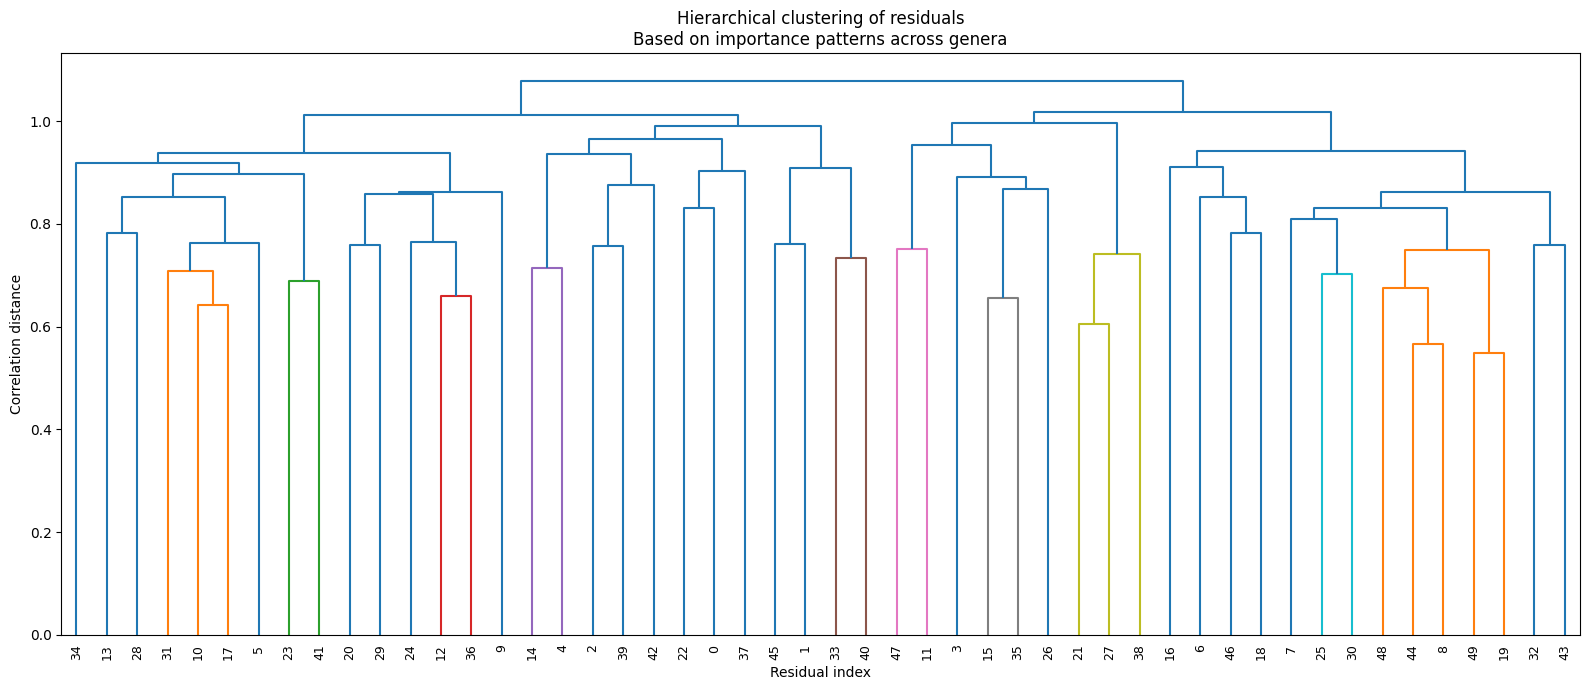

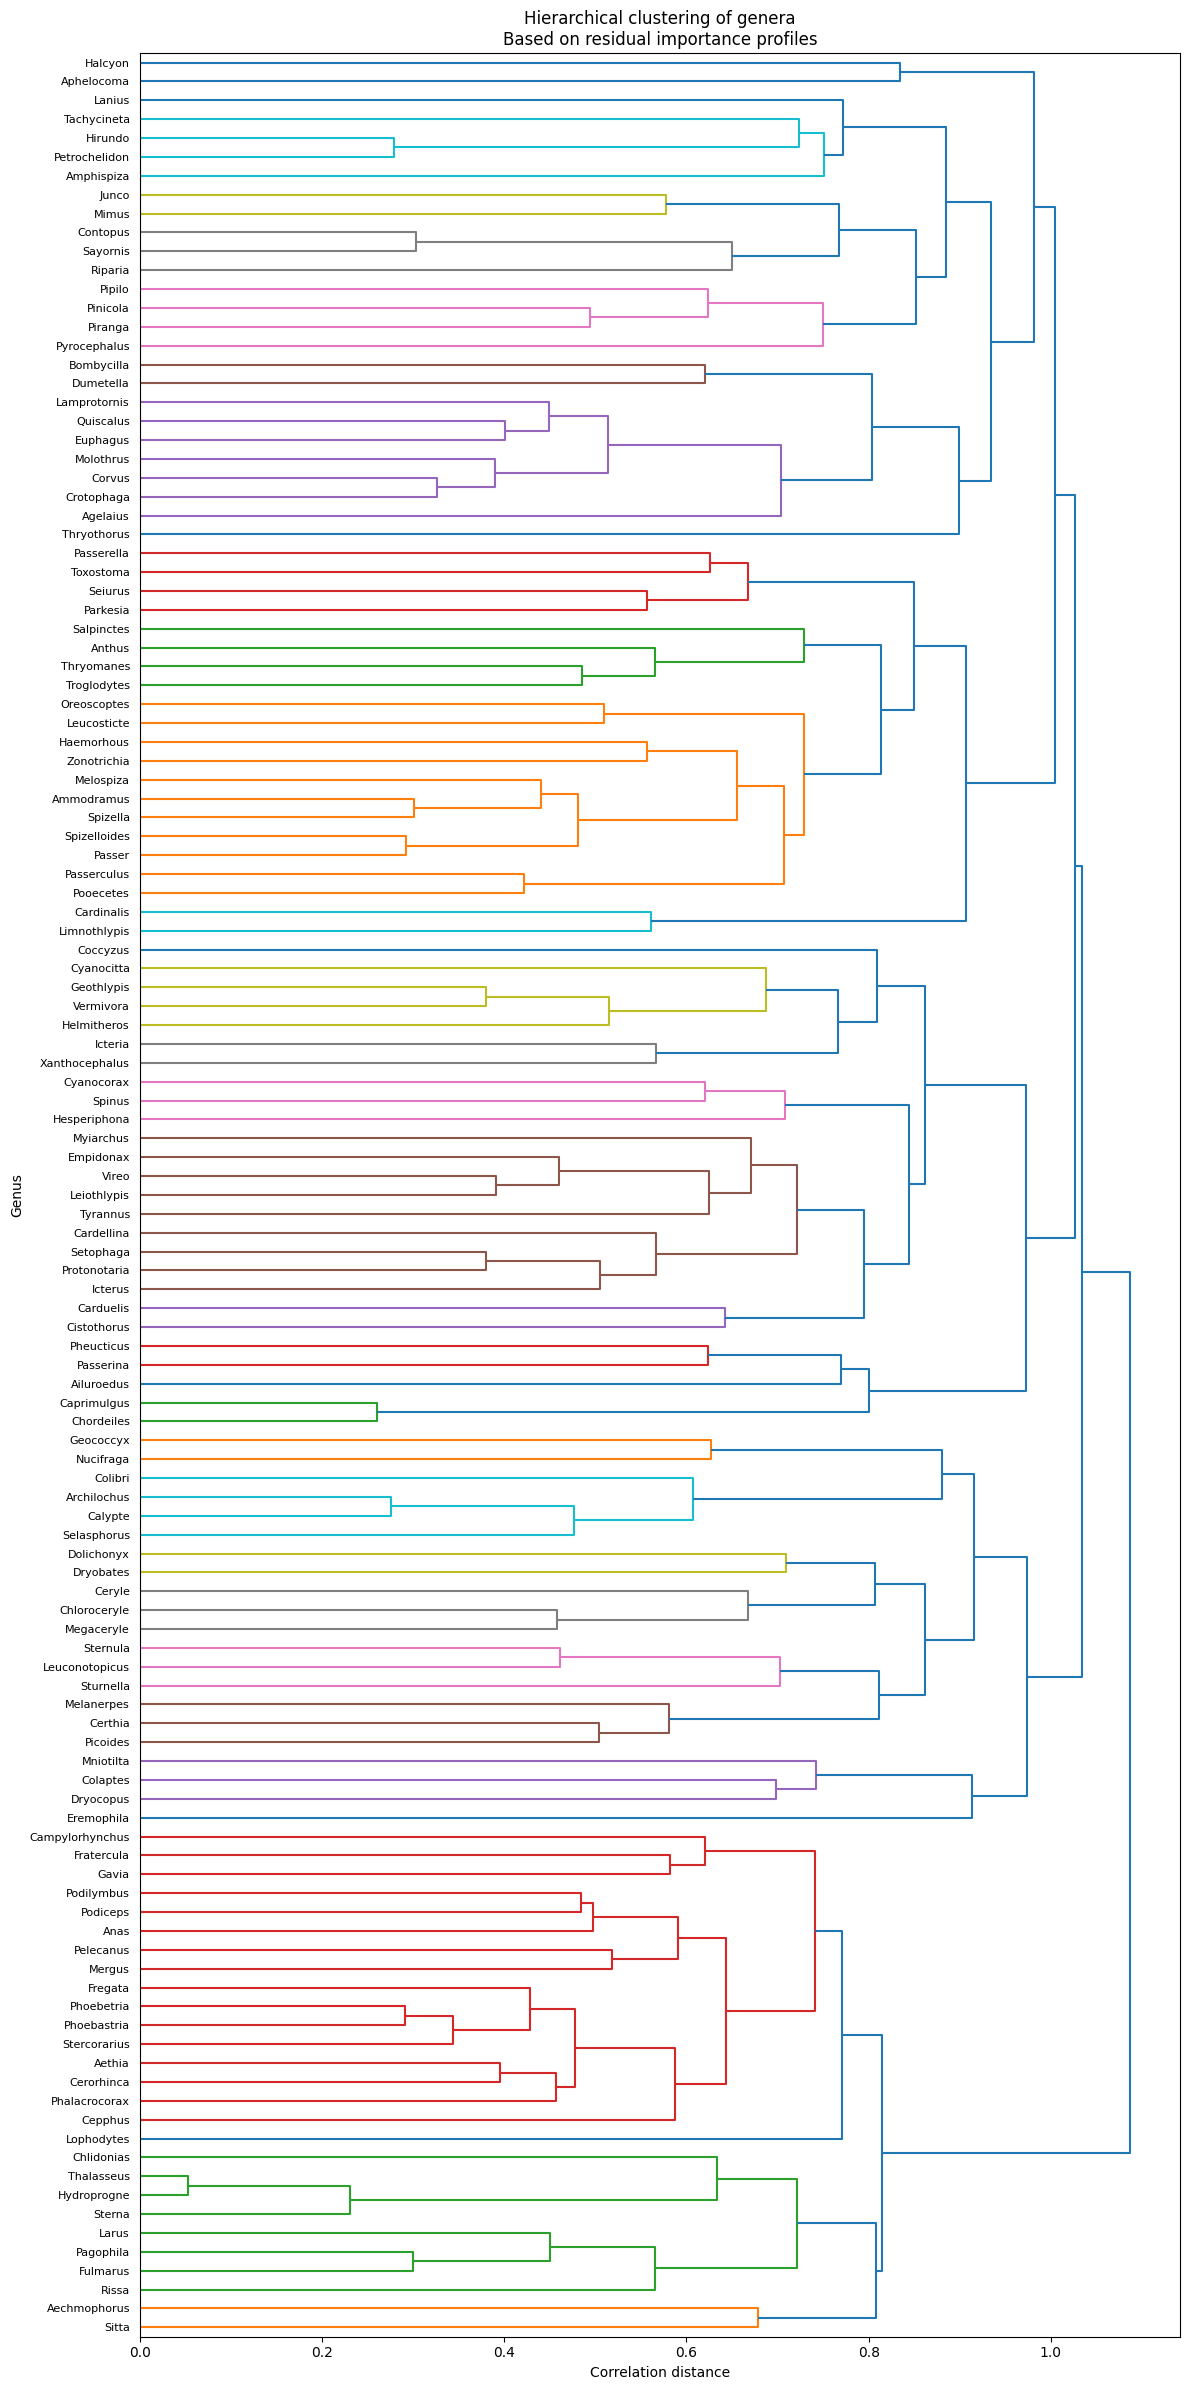

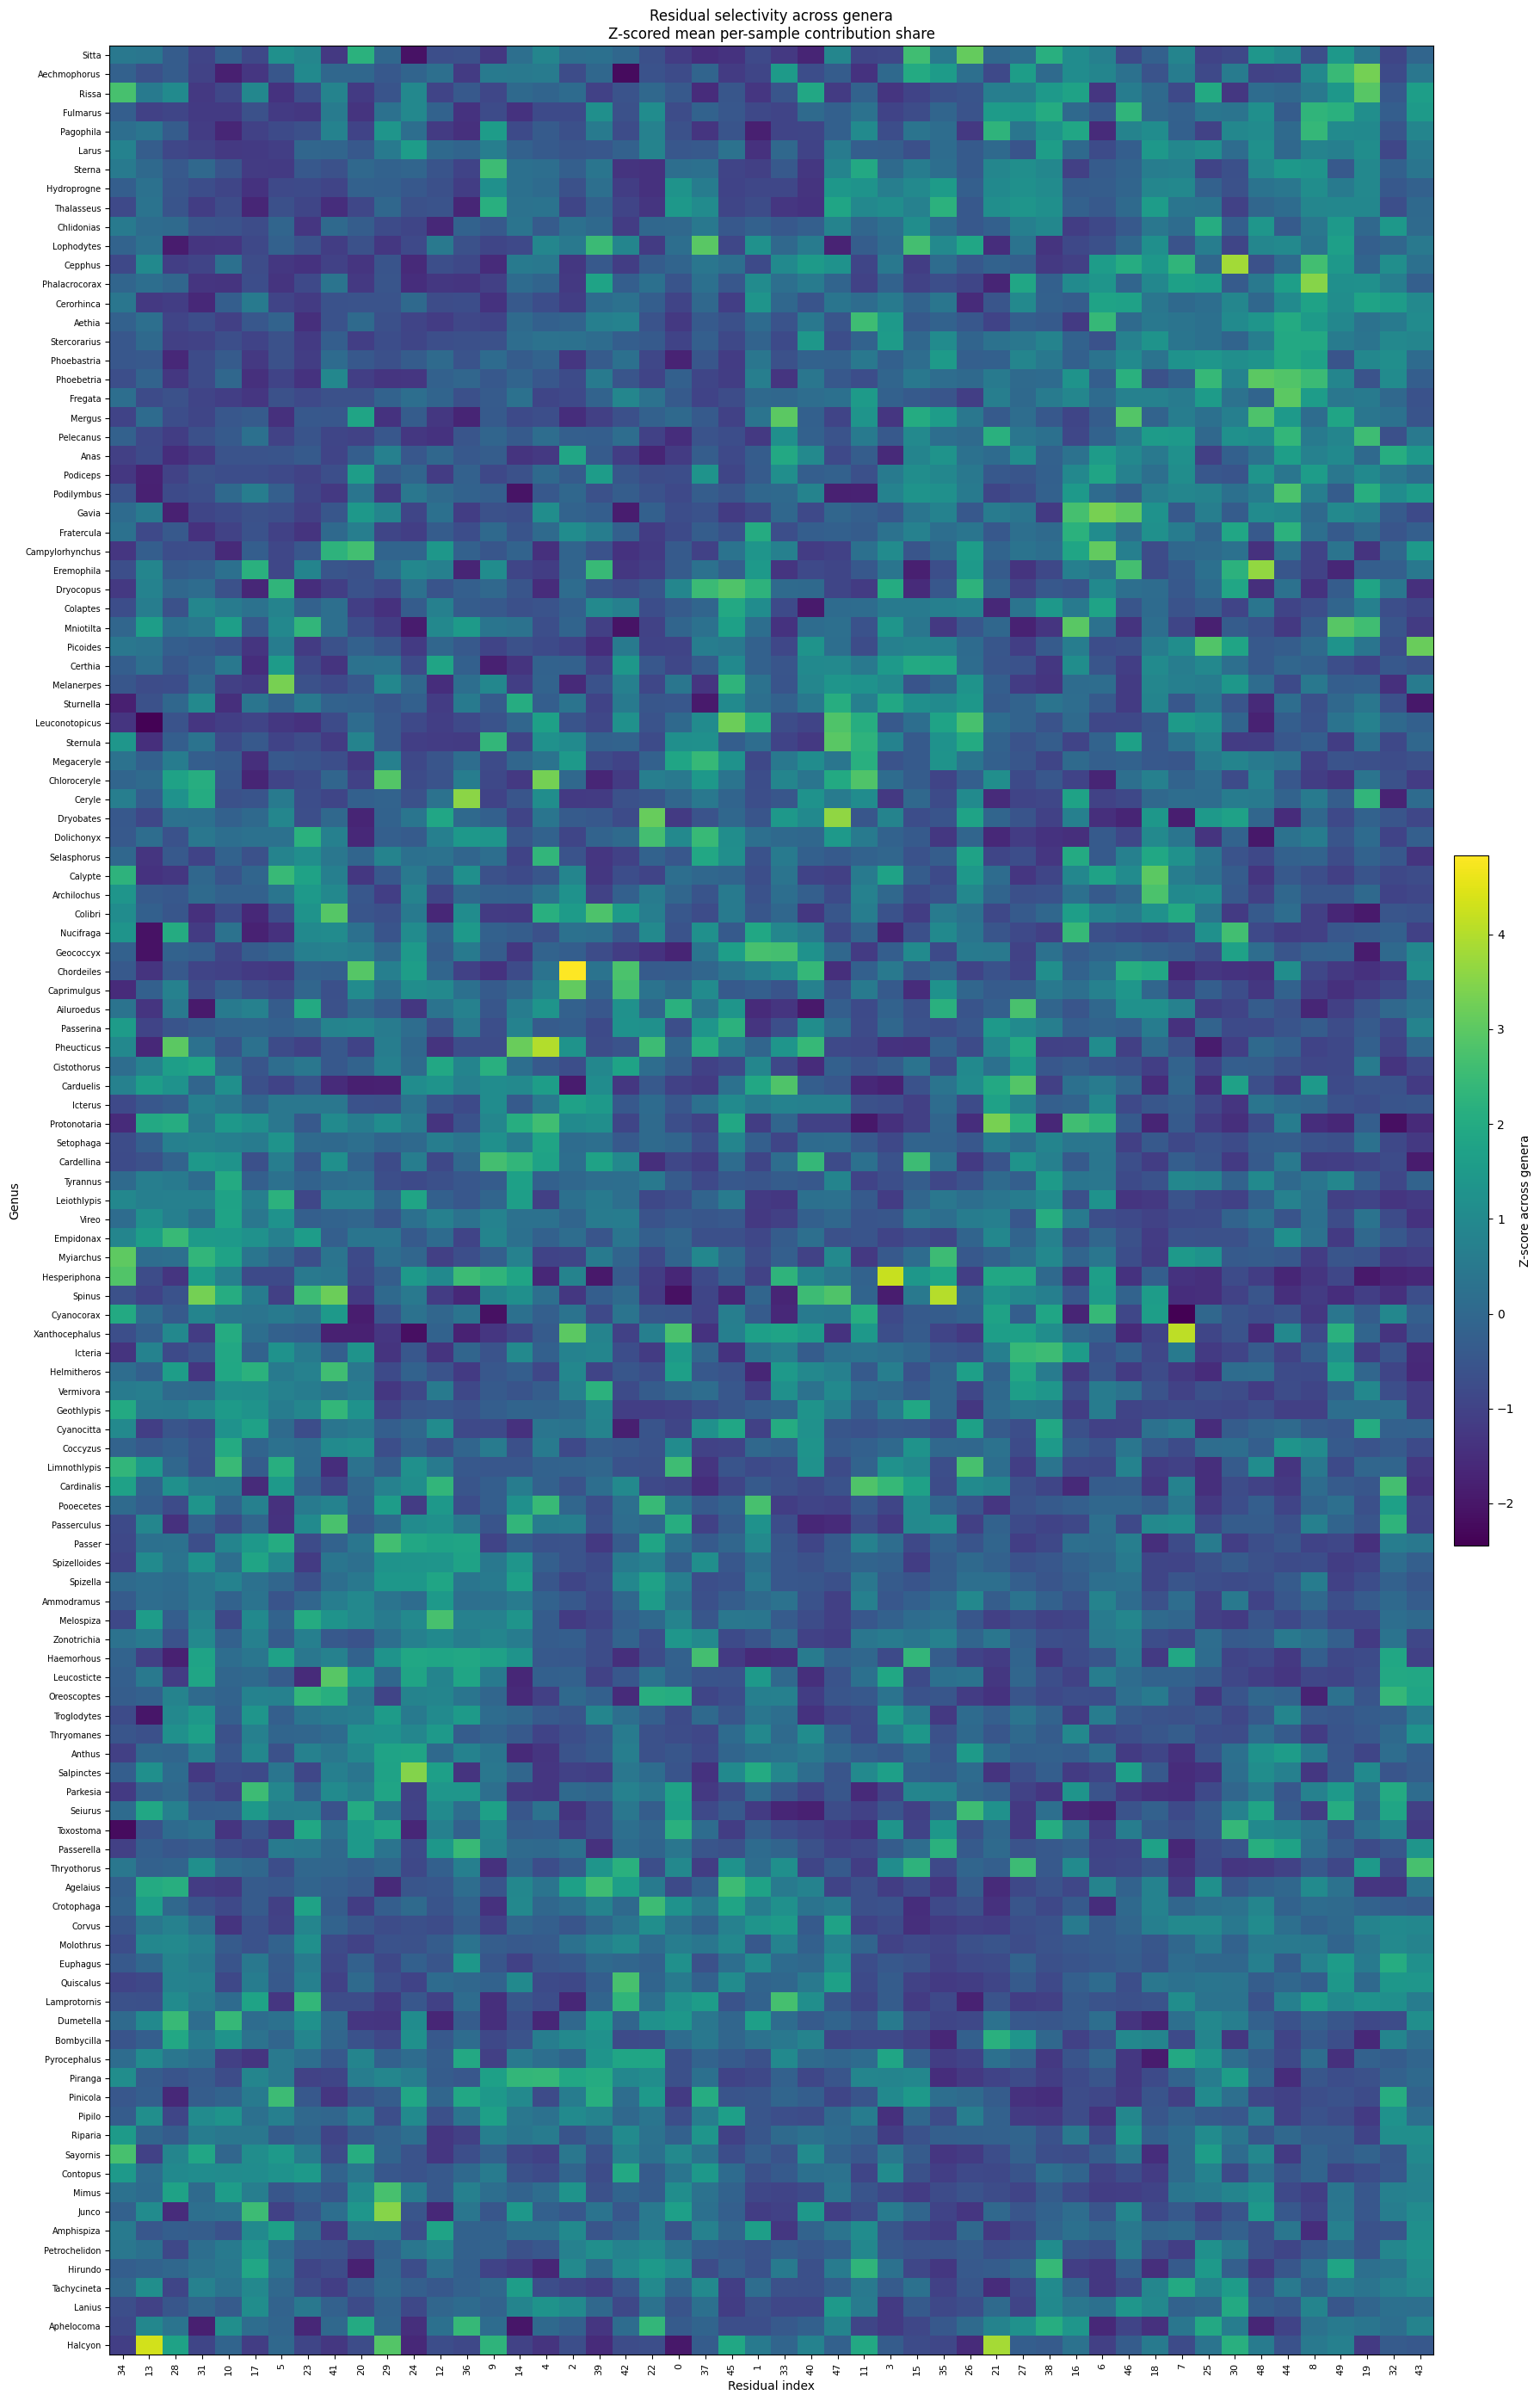

In [20]:
# ============================================================
# Separate plots:
#   1. Residual dendrogram
#   2. Genus dendrogram
#   3. Clustered genus x residual heatmap
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import pdist


# ------------------------------------------------------------
# 1. Create genus x residual matrix
# ------------------------------------------------------------

genus_residual_share = (
    all_residuals_per_genus_df
    .pivot(
        index="genus",
        columns="residual_idx",
        values="mean_per_sample_share",
    )
)

print(
    "Genus x residual matrix:",
    genus_residual_share.shape
)


# ------------------------------------------------------------
# 2. Z-score EACH residual across genera
# ------------------------------------------------------------

genus_residual_z = (
    genus_residual_share
    - genus_residual_share.mean(axis=0)
) / genus_residual_share.std(axis=0, ddof=0)


# ------------------------------------------------------------
# 3. Calculate correlation distances
# ------------------------------------------------------------

# Genera:
# Compare residual-importance patterns between genera
genus_distance = pdist(
    genus_residual_z.values,
    metric="correlation",
)

# Residuals:
# Compare genus-selectivity patterns between residuals
residual_distance = pdist(
    genus_residual_z.values.T,
    metric="correlation",
)


# ------------------------------------------------------------
# 4. Hierarchical clustering
# ------------------------------------------------------------

genus_linkage = linkage(
    genus_distance,
    method="average",
    optimal_ordering=True,
)

residual_linkage = linkage(
    residual_distance,
    method="average",
    optimal_ordering=True,
)


# ------------------------------------------------------------
# 5. Get clustered ordering
# ------------------------------------------------------------

genus_order = leaves_list(genus_linkage)
residual_order = leaves_list(residual_linkage)

clustered_z = genus_residual_z.iloc[
    genus_order,
    residual_order,
]


# ============================================================
# PLOT 1: Residual clustering
# ============================================================

plt.figure(figsize=(16, 7))

dendrogram(
    residual_linkage,
    labels=genus_residual_z.columns.astype(int).astype(str),
    leaf_rotation=90,
    leaf_font_size=9,
)

plt.title(
    "Hierarchical clustering of residuals\n"
    "Based on importance patterns across genera"
)

plt.xlabel("Residual index")
plt.ylabel("Correlation distance")

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2: Genus clustering
# ============================================================

plt.figure(figsize=(12, 24))

dendrogram(
    genus_linkage,
    labels=genus_residual_z.index.astype(str),
    orientation="right",
    leaf_font_size=8,
)

plt.title(
    "Hierarchical clustering of genera\n"
    "Based on residual importance profiles"
)

plt.xlabel("Correlation distance")
plt.ylabel("Genus")

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3: Clustered heatmap
# ============================================================

fig, ax = plt.subplots(
    figsize=(18, 28)
)

im = ax.imshow(
    clustered_z.values,
    aspect="auto",
    interpolation="nearest",
)

# Residual labels
ax.set_xticks(
    np.arange(clustered_z.shape[1])
)

ax.set_xticklabels(
    clustered_z.columns.astype(int),
    rotation=90,
    fontsize=8,
)

# Genus labels
ax.set_yticks(
    np.arange(clustered_z.shape[0])
)

ax.set_yticklabels(
    clustered_z.index,
    fontsize=7,
)

ax.set_xlabel("Residual index")
ax.set_ylabel("Genus")

ax.set_title(
    "Residual selectivity across genera\n"
    "Z-scored mean per-sample contribution share"
)

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.025,
    pad=0.015,
)

cbar.set_label(
    "Z-score across genera"
)

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# Rank all genus x residual pairs by selectivity
# ============================================================

# genus_residual_z:
# rows    = genera
# columns = residual indices
# values  = z-scored mean per-sample contribution share


# ------------------------------------------------------------
# 1. Convert matrix into long-form dataframe
# ------------------------------------------------------------

ranked_pairs = (
    genus_residual_z
    .stack()
    .reset_index()
)

ranked_pairs.columns = [
    "genus",
    "residual_idx",
    "z_score",
]


# ------------------------------------------------------------
# 2. Add original contribution share
# ------------------------------------------------------------

share_long = (
    genus_residual_share
    .stack()
    .reset_index()
)

share_long.columns = [
    "genus",
    "residual_idx",
    "mean_per_sample_share",
]

ranked_pairs = ranked_pairs.merge(
    share_long,
    on=["genus", "residual_idx"],
    how="left",
)


# ------------------------------------------------------------
# 3. Rank pairs
# ------------------------------------------------------------
# Highest z-score =
# residual is unusually important for this genus

ranked_pairs = (
    ranked_pairs
    .sort_values(
        "z_score",
        ascending=False,
    )
    .reset_index(drop=True)
)

ranked_pairs["pair_rank"] = (
    np.arange(1, len(ranked_pairs) + 1)
)


# ------------------------------------------------------------
# 4. Show strongest genus-residual associations
# ------------------------------------------------------------

print(
    ranked_pairs.head(50).to_string(index=False)
)

ranked_pairs.to_csv(
    "delete_afterwards/ranked_genus_residual_pairs_z_scores.csv",
    index=False,
)

          genus  residual_idx  z_score  mean_per_sample_share  pair_rank
     Chordeiles             2 4.832783               0.065626          1
        Halcyon            13 4.336456               0.053360          2
   Hesperiphona             3 4.228029               0.056458          3
 Xanthocephalus             7 4.102516               0.054146          4
         Spinus            35 4.009276               0.064120          5
     Pheucticus             4 3.983581               0.048847          6
        Halcyon            21 3.842562               0.052775          7
        Cepphus            30 3.835228               0.061333          8
     Eremophila            48 3.644096               0.045136          9
      Dryobates            47 3.635631               0.048839         10
         Ceryle            36 3.580333               0.049802         11
  Phalacrocorax             8 3.525456               0.048699         12
          Junco            29 3.509792             

Number of residual - genera pairs with z-score over 2

Top pairs for each residual

In [22]:
# Residual - genera pairs with z-score over 2
strong_residuals_per_genus = (
    ranked_pairs[
        ranked_pairs["z_score"] >= 2
    ]
    .sort_values(
        ["genus", "z_score"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

display(strong_residuals_per_genus.head(20))

print(
    f"Number of residual - genera pairs with z-score >= 2: "
    f"{strong_residuals_per_genus.shape[0]}"
)

strong_residuals_per_genus.to_csv(
    "delete_afterwards/strong_residuals_per_genus_z_scores.csv",
    index=False,
)

,genus,residual_idx,z_score,mean_per_sample_share,pair_rank
0,Aechmophorus,19,3.301984,0.049336,20
1,Aechmophorus,49,2.501148,0.044086,117
2,Aethia,11,2.574101,0.044111,98
3,Aethia,6,2.429084,0.037668,134
4,Aethia,44,2.002306,0.032903,258
5,Agelaius,39,2.575037,0.042139,97
6,Agelaius,45,2.556031,0.046395,102
7,Agelaius,28,2.130139,0.042138,207
8,Agelaius,13,2.017462,0.036033,250
9,Ailuroedus,27,2.757852,0.044968,63


Number of residual - genera pairs with z-score >= 2: 258


In [23]:
# For each residual find the number of genera with z_score >= 2
residual_genus_counts = (
    strong_residuals_per_genus
    .groupby("residual_idx")
    .size()
)

residual_genus_counts.head(50)
residual_genus_counts.to_csv(
    "delete_afterwards/residual_genus_counts_z_score_ge_2.csv",
    header=["num_genera"],
    index=True,
)

Top residuals for each genus

In [24]:
top_residuals_per_genus = (
    ranked_pairs
    .sort_values(
        ["genus", "z_score"],
        ascending=[True, False],
    )
    .groupby("genus")
    .head(10)
    .reset_index(drop=True)
)

print(top_residuals_per_genus)

             genus  residual_idx   z_score  mean_per_sample_share  pair_rank
0     Aechmophorus            19  3.301984               0.049336         20
1     Aechmophorus            49  2.501148               0.044086        117
2     Aechmophorus            15  1.991268               0.038383        260
3     Aechmophorus            27  1.617811               0.034631        455
4     Aechmophorus            35  1.564417               0.037730        486
...            ...           ...       ...                    ...        ...
1205   Zonotrichia            35  0.757494               0.029021       1284
1206   Zonotrichia            24  0.718803               0.027282       1351
1207   Zonotrichia            17  0.713239               0.025037       1357
1208   Zonotrichia            23  0.697074               0.027502       1377
1209   Zonotrichia            36  0.634457               0.024568       1450

[1210 rows x 5 columns]


In [ ]:
# ============================================================
# Find genera that share multiple strongly selective residuals
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Binary genus x residual matrix
# ------------------------------------------------------------
# 1 = residual has z >= 2 for this genus
# 0 = otherwise

binary_matrix = (
    ranked_pairs
    .assign(strong=lambda x: (x["z_score"] >= 2).astype(int))
    .pivot(
        index="genus",
        columns="residual_idx",
        values="strong",
    )
    .fillna(0)
    .astype(int)
)



# ------------------------------------------------------------
# 2. Number of shared strong residuals
# ------------------------------------------------------------

shared_counts = binary_matrix @ binary_matrix.T





# ------------------------------------------------------------
# 3. Convert to ranked dataframe
# ------------------------------------------------------------

rows = []

genera = binary_matrix.index

for i in range(len(genera)):
    for k in range(i + 1, len(genera)):

        genus_1 = genera[i]
        genus_2 = genera[k]

        count = shared_counts.iloc[i, k]

        if count < 2:
            continue

        # Which residuals do they actually share?
        shared_mask = (
            (binary_matrix.loc[genus_1] == 1)
            &
            (binary_matrix.loc[genus_2] == 1)
        )

        shared_residuals = (
            binary_matrix.columns[shared_mask]
            .astype(int)
            .tolist()
        )

        rows.append(
            {
                "genus_1": genus_1,
                "genus_2": genus_2,
                "num_shared_residuals": int(count),
                "shared_residuals": shared_residuals,
            }
        )


shared_residual_pairs = (
    pd.DataFrame(rows)
    .sort_values(
        "num_shared_residuals",
        ascending=False,
    )
    .reset_index(drop=True)
)

shared_residual_pairs

residual_idx  0   1   2   3   4   5   6   7   8   9   ...  40  41  42  43  44  \
genus                                                 ...                       
Aechmophorus   0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
Aethia         0   0   0   0   0   0   1   0   0   0  ...   0   0   0   0   1   
Agelaius       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
Ailuroedus     1   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
Ammodramus     0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
Amphispiza     0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
Anas           0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
Anthus         0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
Aphelocoma     0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
Archilochus    0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   

residual_idx  45  46  47  4

,genus_1,genus_2,num_shared_residuals,shared_residuals
0,Oreoscoptes,Passerculus,3,"[0, 32, 41]"
1,Leuconotopicus,Sternula,3,"[11, 26, 47]"
2,Pheucticus,Protonotaria,3,"[4, 14, 28]"
3,Dryocopus,Leuconotopicus,3,"[1, 26, 45]"
4,Nucifraga,Protonotaria,2,"[16, 28]"
5,Limnothlypis,Xanthocephalus,2,"[0, 10]"
6,Lophodytes,Pinicola,2,"[37, 39]"
7,Mergus,Phoebetria,2,"[46, 48]"
8,Myiarchus,Spinus,2,"[31, 35]"
9,Aechmophorus,Mniotilta,2,"[19, 49]"


## Family analysis

In [25]:
cub_taxonomy_df.head(10)

family_to_class_idx_dict = {}

for _, row in cub_taxonomy_df.iterrows():
    family = row["family"]
    class_idx = row["class_idx"]

    if pd.isna(family):
        continue

    if family not in family_to_class_idx_dict:
        family_to_class_idx_dict[family] = []

    family_to_class_idx_dict[family].append(class_idx)
    
print("Family to class_idx mapping:")
for family, class_indices in family_to_class_idx_dict.items():
    print(f"  {family}: {class_indices}")

Family to class_idx mapping:
  Diomedeidae: [0, 1, 2]
  Cuculidae: [3, 30, 31, 32, 109]
  Alcidae: [4, 5, 6, 7, 57, 105]
  Icteridae: [8, 9, 10, 11, 12, 25, 26, 48, 87, 94, 95, 96, 97]
  Cardinalidae: [13, 14, 15, 16, 53, 56, 138, 139]
  Ptilonorhynchidae: [17]
  Mimidae: [18, 90, 148, 149]
  Icteriidae: [19]
  Passerellidae: [20, 75, 112, 113, 114, 115, 116, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 147]
  Caprimulgidae: [21, 91, 104]
  Phalacrocoracidae: [22, 23, 24]
  Certhiidae: [27]
  Corvidae: [28, 29, 72, 73, 74, 92, 106, 107]
  Fringillidae: [33, 34, 46, 47, 54, 55]
  Picidae: [35, 186, 187, 188, 189, 190, 191]
  Tyrannidae: [36, 37, 38, 39, 40, 41, 42, 76, 77, 101, 102]
  Fregatidae: [43]
  Procellariidae: [44]
  Anatidae: [45, 86, 88, 89]
  Podicipedidae: [49, 50, 51, 52]
  Laridae: [58, 59, 60, 61, 62, 63, 64, 65, 83, 140, 141, 142, 143, 144, 145, 146]
  Trochilidae: [66, 67, 68, 69]
  Stercorariidae: [70, 71]
  Alcedinidae: [78, 79, 80, 81, 

In [35]:
import pickle
with open("/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/datasets/CUB/class_attr_data_10/train.pkl", "rb") as f:
    train_data = pickle.load(f)
    
print(train_data[0].keys())

for i in range(10):
    print(f"Sample {i}:")
    print(f"  Image path: {train_data[i]['img_path']}")
    print(f"  Class index: {train_data[i]['class_label']}")
    print(f"  ID: {train_data[i]['id']}")


/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_95139/280016815.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  train_data = pickle.load(f)


dict_keys(['id', 'img_path', 'class_label', 'attribute_label', 'attribute_certainty'])
Sample 0:
  Image path: /juice/scr/scr102/scr/thaonguyen/CUB_supervision/datasets/CUB_200_2011/images/022.Chuck_will_Widow/Chuck_Will_Widow_0059_796982.jpg
  Class index: 21
  ID: 1210
Sample 1:
  Image path: /juice/scr/scr102/scr/thaonguyen/CUB_supervision/datasets/CUB_200_2011/images/052.Pied_billed_Grebe/Pied_Billed_Grebe_0070_35472.jpg
  Class index: 51
  ID: 2987
Sample 2:
  Image path: /juice/scr/scr102/scr/thaonguyen/CUB_supervision/datasets/CUB_200_2011/images/063.Ivory_Gull/Ivory_Gull_0089_49699.jpg
  Class index: 62
  ID: 3621
Sample 3:
  Image path: /juice/scr/scr102/scr/thaonguyen/CUB_supervision/datasets/CUB_200_2011/images/169.Magnolia_Warbler/Magnolia_Warbler_0015_165817.jpg
  Class index: 168
  ID: 9938
Sample 4:
  Image path: /juice/scr/scr102/scr/thaonguyen/CUB_supervision/datasets/CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0077_796114.jpg
  Class index: 0

In [40]:
with open("/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/datasets/CUB/class_attr_data_10/train.pkl", "rb") as f:
    dataset = pickle.load(f)

for i in range(10):

    parts = dataset[i]["img_path"].split("/")
    index = parts.index("images")
    end_path = "/".join(parts[index + 1:])


    new_path = os.path.join(
        "datasets", "TravelingBirds/train/", end_path
    )
    
    assert os.path.exists(new_path), f"Path does not exist: {new_path}"

    print(new_path)






datasets/TravelingBirds/train/022.Chuck_will_Widow/Chuck_Will_Widow_0059_796982.jpg
datasets/TravelingBirds/train/052.Pied_billed_Grebe/Pied_Billed_Grebe_0070_35472.jpg
datasets/TravelingBirds/train/063.Ivory_Gull/Ivory_Gull_0089_49699.jpg
datasets/TravelingBirds/train/169.Magnolia_Warbler/Magnolia_Warbler_0015_165817.jpg
datasets/TravelingBirds/train/001.Black_footed_Albatross/Black_Footed_Albatross_0077_796114.jpg
datasets/TravelingBirds/train/071.Long_tailed_Jaeger/Long_Tailed_Jaeger_0009_797070.jpg
datasets/TravelingBirds/train/025.Pelagic_Cormorant/Pelagic_Cormorant_0038_23643.jpg
datasets/TravelingBirds/train/101.White_Pelican/White_Pelican_0042_97250.jpg
datasets/TravelingBirds/train/097.Orchard_Oriole/Orchard_Oriole_0084_91658.jpg
datasets/TravelingBirds/train/127.Savannah_Sparrow/Savannah_Sparrow_0091_120630.jpg


/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_95139/3986842605.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dataset = pickle.load(f)
